In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
SRC = "/content/drive/MyDrive/tagging/test.h5"
# 目标路径 (Colab 临时盘)
DST = "/content/test.h5"

!rsync -ah --info=progress2 "$SRC" "$DST"

          8.16G 100%   83.93MB/s    0:01:32 (xfr#1, to-chk=0/1)


In [1]:
import os
import sys
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split


# ROOT_DIR = os.getcwd()
# DATA_DIR = ROOT_DIR
# THIS_DIR = f'{ROOT_DIR}/drive/MyDrive/tagging/pure_unsmear/joint_final'
# MODULE_DIR = THIS_DIR
# TAGGING_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))

THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
TAGGING_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))
DATA_DIR = os.path.abspath(os.path.join(TAGGING_DIR, '..'))


sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import model as model_mod  # noqa: E402
import importlib  # noqa: E402
importlib.reload(tool)  # noqa: E402
importlib.reload(model_mod)  # noqa: E402
from model import ParticleTransformerKD, SharedEncoderUnsmearClassifier  # noqa: E402

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

RUN_NAME = 'unsmear_transformer_sharedencoder_delta_gate_joint_repeat3'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')
METRICS_DIR = os.path.join(OUT_DIR, 'metrics')
REPEAT_DIR = os.path.join(OUT_DIR, 'repeats')
TABLE_DIR = os.path.join(OUT_DIR, 'tables')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)
tool.ensure_dir(METRICS_DIR)
tool.ensure_dir(REPEAT_DIR)
tool.ensure_dir(TABLE_DIR)

CONFIG = {
    'data_path': os.path.join(DATA_DIR, 'test.h5'),
    'n_jets': 500000,
    'max_particles': 100,
    'feature_kind': '7d',
    'repeat_seeds': [42, 52, 62],
    'load_shared_baselines': True,
    'load_joint_model': True,
    'joint_model': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
        'unsmear_decoder_layers': 2,
        'unsmear_decoder_heads': 8,
        'unsmear_decoder_ff_dim': 512,
        'unsmear_decoder_dropout': 0.1,
        'return_reco': True,
        'add_mask_channel': False,
        'mask_output': True,
        'use_positional_embedding': False,
        'max_seq_len': 128,
        'cls_use_delta_fusion': True,
        'cls_detach_delta_for_cls': False,
        'cls_gate_hidden_dim': 128,
        'cls_gate_init_bias': -2.0,
        'cls_alpha_init': 0.05,
    },
    'hlt_effects': {
        'pt_threshold_offline': 0,
        'pt_threshold_hlt': 0,
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
    },
    'tagger': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 6,
        'ff_dim': 512,
        'dropout': 0.1,
    },
    'kd': {
        'enable': True,
        'temperature': 2.0,
        'alpha_kd': 0.5,
        'alpha_attn': 0,
    },
    'training': {
        'batch_size': 1024,
        'epochs': 70,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 5,
        'patience': 8,
        'early_stop_metric': 'val_auc',
        'use_sample_weight_for_all_losses': False,
        'joint_unsmear_weight': 1.6,
        'joint_cls_weight': 0.8,
        'joint_phys_weight': 0.0,
        'feature_loss_weights': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
        'resmear_each_epoch_baselines': True,
        'resmear_each_epoch_joint': True,
        'resmear_seed_stride': 1,
    },
}

feat_names = tool.get_feat_names(CONFIG['feature_kind'])
CONFIG['joint_model']['input_dim'] = len(feat_names)
CONFIG['joint_model']['max_seq_len'] = int(CONFIG['max_particles'])
CONFIG['tagger']['input_dim'] = len(feat_names)

feature_loss_weights = np.asarray(CONFIG['training']['feature_loss_weights'], dtype=np.float32)
if feature_loss_weights.shape[0] != len(feat_names):
    raise ValueError(
        f"Expected {len(feat_names)} feature weights for {CONFIG['feature_kind']}, got {feature_loss_weights.shape[0]}"
    )
CONFIG['training']['feature_loss_weights'] = feature_loss_weights.tolist()
CONFIG['training']['use_sample_weight_for_all_losses'] = bool(
    CONFIG['training'].get('use_sample_weight_for_all_losses', True)
)

config_path = os.path.join(OUT_DIR, 'config.json')
tool.save_config(CONFIG, config_path)
print('Data path:', CONFIG['data_path'])
print('Run dir:', OUT_DIR)
print('Feature kind:', CONFIG['feature_kind'], 'feat_names:', feat_names)
print('Repeat seeds:', CONFIG['repeat_seeds'])
print('Feature loss weights:', dict(zip(feat_names, np.round(feature_loss_weights, 4))))
print('Joint physical consistency weight:', float(CONFIG['training']['joint_phys_weight']))
print('Use sample weight for all losses:', bool(CONFIG['training']['use_sample_weight_for_all_losses']))
print('Delta fusion enabled:', bool(CONFIG['joint_model']['cls_use_delta_fusion']))
print('Detach delta for classifier:', bool(CONFIG['joint_model']['cls_detach_delta_for_cls']))
print('Gate hidden dim:', int(CONFIG['joint_model']['cls_gate_hidden_dim']))
print('Gate init bias:', float(CONFIG['joint_model']['cls_gate_init_bias']))
print('Alpha init:', float(CONFIG['joint_model']['cls_alpha_init']))


Device: cuda
Data path: d:\PracticeTagging\tagging\test.h5
Run dir: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3
Feature kind: 7d feat_names: ['dEta', 'dPhi', 'log_pt', 'log_E', 'log_pt_rel', 'log_E_rel', 'dR']
Repeat seeds: [42, 52, 62]
Feature loss weights: {'dEta': np.float32(1.0), 'dPhi': np.float32(1.0), 'log_pt': np.float32(1.0), 'log_E': np.float32(1.0), 'log_pt_rel': np.float32(1.0), 'log_E_rel': np.float32(1.0), 'dR': np.float32(1.0)}
Joint physical consistency weight: 0.0
Use sample weight for all losses: False
Delta fusion enabled: True
Detach delta for classifier: False
Gate hidden dim: 128
Gate init bias: -2.0
Alpha init: 0.05


In [2]:
# Load the raw constituents and build the offline / HLT views
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)
mask_raw = pt > 0
print('Raw:', constituents_raw.shape, 'mask:', mask_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))

hcfg = tool.HLTEffectsCfg(**CONFIG['hlt_effects'])
_, hlt_const, hlt_mask = tool.apply_hlt_effects_pair(
    constituents_raw,
    mask_raw,
    hcfg,
    seed=seed,
)

pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
off_mask = mask_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
off_const = constituents_raw.copy()
off_const[~off_mask] = 0.0
hlt_const = hlt_const.copy()
hlt_const[~hlt_mask] = 0.0

axis_off = tool.compute_jet_axis(off_const, off_mask)
axis_hlt = tool.compute_jet_axis(hlt_const, hlt_mask)
feat_off = tool.compute_features_with_axis(off_const, off_mask, axis_off, kind=CONFIG['feature_kind'])
feat_hlt = tool.compute_features_with_axis(hlt_const, hlt_mask, axis_hlt, kind=CONFIG['feature_kind'])

idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=1/3, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=seed, stratify=labels[temp_idx])
print(f'Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}')

feat_means, feat_stds = tool.get_stats(feat_off, off_mask, train_idx)
feat_off_std = tool.standardize(feat_off, off_mask, feat_means, feat_stds, clip=10.0)
feat_hlt_std = tool.standardize(feat_hlt, hlt_mask, feat_means, feat_stds, clip=10.0)
common_mask = off_mask & hlt_mask

x_joint = feat_hlt_std.copy()
y_joint = feat_off_std.copy()
x_joint[~common_mask] = 0.0
y_joint[~common_mask] = 0.0

train_const_raw = constituents_raw[train_idx]
train_mask_raw = mask_raw[train_idx]

print('Offline/HLT feature shape:', feat_off_std.shape, feat_hlt_std.shape)
print('Mask identical:', bool(np.array_equal(off_mask, hlt_mask)))
print('Common-mask fraction:', float(common_mask.mean()))
print('Feat means:', np.round(feat_means, 4))
print('Feat stds :', np.round(feat_stds, 4))
print('Baseline epoch resmear enabled:', bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)))
print('Joint epoch resmear enabled:', bool(CONFIG['training'].get('resmear_each_epoch_joint', False)))


Raw: (500000, 100, 4) mask: (500000, 100)
Signal: 249553 Bkg: 250447
Split: train=333,333 val=83,333 test=83,334
Offline/HLT feature shape: (500000, 100, 7) (500000, 100, 7)
Mask identical: True
Common-mask fraction: 0.54299542
Feat means: [ 0.      0.      8.7943  9.0852 -5.2579 -5.2696  0.2228]
Feat stds : [0.2123 0.2177 1.5181 1.5215 1.491  1.4928 0.2069]
Baseline epoch resmear enabled: True
Joint epoch resmear enabled: True


In [3]:
# Build the datasets and loaders
BS = int(CONFIG['training']['batch_size'])
train_ds_hlt = tool.JetDataset(
    feat_off_std[train_idx],
    feat_hlt_std[train_idx],
    labels[train_idx],
    off_mask[train_idx],
    hlt_mask[train_idx],
    weights[train_idx],
)
val_ds_hlt = tool.JetDataset(
    feat_off_std[val_idx],
    feat_hlt_std[val_idx],
    labels[val_idx],
    off_mask[val_idx],
    hlt_mask[val_idx],
    weights[val_idx],
)
test_ds_hlt = tool.JetDataset(
    feat_off_std[test_idx],
    feat_hlt_std[test_idx],
    labels[test_idx],
    off_mask[test_idx],
    hlt_mask[test_idx],
    weights[test_idx],
)

train_ds_joint = tool.JointJetDataset(
    x_joint[train_idx],
    y_joint[train_idx],
    common_mask[train_idx],
    labels[train_idx],
    weights[train_idx],
)
val_ds_joint = tool.JointJetDataset(
    x_joint[val_idx],
    y_joint[val_idx],
    common_mask[val_idx],
    labels[val_idx],
    weights[val_idx],
)
test_ds_joint = tool.JointJetDataset(
    x_joint[test_idx],
    y_joint[test_idx],
    common_mask[test_idx],
    labels[test_idx],
    weights[test_idx],
)

train_loader_hlt = DataLoader(train_ds_hlt, batch_size=BS, shuffle=True, drop_last=True)
val_loader_hlt = DataLoader(val_ds_hlt, batch_size=BS, shuffle=False)
test_loader_hlt = DataLoader(test_ds_hlt, batch_size=BS, shuffle=False)

train_loader_joint = DataLoader(train_ds_joint, batch_size=BS, shuffle=True, drop_last=True)
val_loader_joint = DataLoader(val_ds_joint, batch_size=BS, shuffle=False)
test_loader_joint = DataLoader(test_ds_joint, batch_size=BS, shuffle=False)


def make_epoch_hlt_train_loader(epoch: int):
    return tool.make_epoch_hlt_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        feat_off_train=feat_off_std[train_idx],
        off_mask_train=off_mask[train_idx],
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=seed,
        fixed_feat_hlt_train=feat_hlt_std[train_idx],
        fixed_hlt_mask_train=hlt_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)),
        clip=10.0,
    )


def make_epoch_joint_train_loader(epoch: int):
    return tool.make_epoch_joint_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=seed,
        fixed_x_train=x_joint[train_idx],
        fixed_y_train=y_joint[train_idx],
        fixed_mask_train=common_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_joint', True)),
        clip=10.0,
    )


In [6]:
# 把所有模型按不同 seed 跑三次，并保存每次的 ckpt / metrics / predictions。
train_cfg = CONFIG['training']
kd_cfg = CONFIG['kd']
use_sample_weight_for_all_losses = bool(train_cfg.get('use_sample_weight_for_all_losses', True))
joint_feature_loss_weights = np.asarray(train_cfg['feature_loss_weights'], dtype=np.float32)
REPEAT_SEEDS = [int(x) for x in CONFIG.get('repeat_seeds', [42, 52, 62])]


def _set_repeat_seed(seed_value: int):
    np.random.seed(int(seed_value))
    torch.manual_seed(int(seed_value))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed_value))


def _make_repeat_hlt_train_loader(epoch: int, repeat_seed: int):
    return tool.make_epoch_hlt_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        feat_off_train=feat_off_std[train_idx],
        off_mask_train=off_mask[train_idx],
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=int(repeat_seed),
        fixed_feat_hlt_train=feat_hlt_std[train_idx],
        fixed_hlt_mask_train=hlt_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_baselines', False)),
        clip=10.0,
    )


def _make_repeat_joint_train_loader(epoch: int, repeat_seed: int):
    return tool.make_epoch_joint_train_loader(
        epoch=int(epoch),
        batch_size=BS,
        labels_train=labels[train_idx],
        weights_train=weights[train_idx],
        train_const_raw=train_const_raw,
        train_mask_raw=train_mask_raw,
        cfg=hcfg,
        feature_kind=CONFIG['feature_kind'],
        means=feat_means,
        stds=feat_stds,
        seed=int(repeat_seed),
        fixed_x_train=x_joint[train_idx],
        fixed_y_train=y_joint[train_idx],
        fixed_mask_train=common_mask[train_idx],
        seed_stride=int(CONFIG['training'].get('resmear_seed_stride', 1)),
        resmear_each_epoch=bool(CONFIG['training'].get('resmear_each_epoch_joint', True)),
        clip=10.0,
    )


def _find_existing_repeat_dir(repeat_seed: int):
    target_suffix = f'_seed_{int(repeat_seed)}'
    if not os.path.isdir(REPEAT_DIR):
        return None
    candidates = []
    for name in os.listdir(REPEAT_DIR):
        full = os.path.join(REPEAT_DIR, name)
        if os.path.isdir(full) and str(name).endswith(target_suffix):
            candidates.append(full)
    if not candidates:
        return None
    candidates.sort()
    return candidates[0]


def _repeat_artifact_paths(repeat_dir: str):
    repeat_ckpt_dir = os.path.join(repeat_dir, 'ckpts')
    repeat_metrics_dir = os.path.join(repeat_dir, 'metrics')
    repeat_pred_dir = os.path.join(repeat_dir, 'predictions')
    return {
        'repeat_dir': repeat_dir,
        'repeat_ckpt_dir': repeat_ckpt_dir,
        'repeat_metrics_dir': repeat_metrics_dir,
        'repeat_pred_dir': repeat_pred_dir,
        'epoch_metrics_paths': {
            'teacher_off': os.path.join(repeat_metrics_dir, 'teacher_off_epoch_metrics.csv'),
            'student_hlt': os.path.join(repeat_metrics_dir, 'student_hlt_epoch_metrics.csv'),
            'hlt_kd': os.path.join(repeat_metrics_dir, 'hlt_kd_epoch_metrics.csv'),
            'joint_no_kd': os.path.join(repeat_metrics_dir, 'joint_no_kd_epoch_metrics.csv'),
            'joint_with_kd': os.path.join(repeat_metrics_dir, 'joint_with_kd_epoch_metrics.csv'),
        },
        'ckpt_paths': {
            'Teacher(OFF_FULL)': os.path.join(repeat_ckpt_dir, 'teacher_offline.pt'),
            'Student(HLT)': os.path.join(repeat_ckpt_dir, 'student_hlt.pt'),
            'Student(HLT)+KD': os.path.join(repeat_ckpt_dir, 'student_hlt_kd.pt'),
            'JointSharedEncoder(HLT,no_kd)': os.path.join(repeat_ckpt_dir, 'joint_sharedencoder_no_kd.pt'),
            'JointSharedEncoder(HLT,with_kd)': os.path.join(repeat_ckpt_dir, 'joint_sharedencoder_with_kd.pt'),
        },
        'prediction_paths': {
            'Teacher(OFF_FULL)': os.path.join(repeat_pred_dir, 'teacher_offline_test_preds.npz'),
            'Student(HLT)': os.path.join(repeat_pred_dir, 'student_hlt_test_preds.npz'),
            'Student(HLT)+KD': os.path.join(repeat_pred_dir, 'student_hlt_kd_test_preds.npz'),
            'JointSharedEncoder(HLT,no_kd)': os.path.join(repeat_pred_dir, 'joint_sharedencoder_no_kd_test_preds.npz'),
            'JointSharedEncoder(HLT,with_kd)': os.path.join(repeat_pred_dir, 'joint_sharedencoder_with_kd_test_preds.npz'),
        },
    }


def _load_prediction_bundle(path: str):
    data = np.load(path)
    return {
        'preds': np.asarray(data['preds'], dtype=np.float32),
        'labels': np.asarray(data['labels'], dtype=np.float32),
        'weights': np.asarray(data['weights'], dtype=np.float32),
    }


def _load_existing_repeat_result(repeat_idx: int, repeat_seed: int):
    repeat_dir = _find_existing_repeat_dir(int(repeat_seed))
    if repeat_dir is None:
        return None

    artifacts = _repeat_artifact_paths(repeat_dir)
    required_paths = []
    required_paths.extend(list(artifacts['ckpt_paths'].values()))
    required_paths.extend(list(artifacts['prediction_paths'].values()))
    required_paths.extend(list(artifacts['epoch_metrics_paths'].values()))
    missing_paths = [p for p in required_paths if not os.path.isfile(p)]
    if missing_paths:
        print(f'Seed {repeat_seed}: found existing folder but artifacts are incomplete, retrain this seed.')
        for p in missing_paths[:5]:
            print('  missing:', p)
        if len(missing_paths) > 5:
            print(f'  ... and {len(missing_paths) - 5} more missing files')
        return None

    model_to_metric_key = {
        'Teacher(OFF_FULL)': 'teacher_off',
        'Student(HLT)': 'student_hlt',
        'Student(HLT)+KD': 'hlt_kd',
        'JointSharedEncoder(HLT,no_kd)': 'joint_no_kd',
        'JointSharedEncoder(HLT,with_kd)': 'joint_with_kd',
    }

    models = {}
    for model_name, pred_path in artifacts['prediction_paths'].items():
        bundle = _load_prediction_bundle(pred_path)
        sample_weight = np.asarray(bundle['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
        _fpr, _tpr, auc, auc_weighted = tool.compute_roc(bundle['labels'], bundle['preds'], sample_weight=sample_weight)
        models[model_name] = {
            'auc': float(auc),
            'auc_weighted': float(auc_weighted),
            'preds': bundle['preds'],
            'labels': bundle['labels'],
            'weights': bundle['weights'],
            'ckpt_path': artifacts['ckpt_paths'][model_name],
            'prediction_path': pred_path,
            'epoch_metrics_path': artifacts['epoch_metrics_paths'][model_to_metric_key[model_name]],
        }

    print(f'Seed {repeat_seed}: found existing repeat folder, load and skip training -> {repeat_dir}')
    return {
        'repeat_idx': int(repeat_idx),
        'repeat_seed': int(repeat_seed),
        'repeat_dir': repeat_dir,
        'models': models,
    }


repeat_results = []
print('Repeat seeds:', REPEAT_SEEDS)

for repeat_idx, repeat_seed in enumerate(REPEAT_SEEDS):
    print()
    print(f'==== Repeat {repeat_idx + 1}/{len(REPEAT_SEEDS)} seed={repeat_seed} ====')
    cached_repeat_result = _load_existing_repeat_result(int(repeat_idx), int(repeat_seed))
    if cached_repeat_result is not None:
        repeat_results.append(cached_repeat_result)
        continue

    _set_repeat_seed(int(repeat_seed))

    repeat_dir = os.path.join(REPEAT_DIR, f'repeat_{int(repeat_idx):02d}_seed_{int(repeat_seed)}')
    repeat_ckpt_dir = os.path.join(repeat_dir, 'ckpts')
    repeat_metrics_dir = os.path.join(repeat_dir, 'metrics')
    repeat_pred_dir = os.path.join(repeat_dir, 'predictions')
    tool.ensure_dir(repeat_dir)
    tool.ensure_dir(repeat_ckpt_dir)
    tool.ensure_dir(repeat_metrics_dir)
    tool.ensure_dir(repeat_pred_dir)

    epoch_metrics_paths = {
        'teacher_off': os.path.join(repeat_metrics_dir, 'teacher_off_epoch_metrics.csv'),
        'student_hlt': os.path.join(repeat_metrics_dir, 'student_hlt_epoch_metrics.csv'),
        'hlt_kd': os.path.join(repeat_metrics_dir, 'hlt_kd_epoch_metrics.csv'),
        'joint_no_kd': os.path.join(repeat_metrics_dir, 'joint_no_kd_epoch_metrics.csv'),
        'joint_with_kd': os.path.join(repeat_metrics_dir, 'joint_with_kd_epoch_metrics.csv'),
    }

    hlt_train_loader_factory = (
        (lambda epoch, repeat_seed=repeat_seed: _make_repeat_hlt_train_loader(epoch, int(repeat_seed)))
        if bool(train_cfg.get('resmear_each_epoch_baselines', False))
        else None
    )
    joint_train_loader_factory = (
        (lambda epoch, repeat_seed=repeat_seed: _make_repeat_joint_train_loader(epoch, int(repeat_seed)))
        if bool(train_cfg.get('resmear_each_epoch_joint', True))
        else None
    )

    teacher = ParticleTransformerKD(**CONFIG['tagger']).to(device)
    teacher_ckpt = os.path.join(repeat_ckpt_dir, 'teacher_offline.pt')
    teacher = tool.train_or_load_standard_model(
        'Teacher(OFF_FULL)',
        teacher,
        teacher_ckpt,
        train_loader_hlt,
        val_loader_hlt,
        device=device,
        feat_key='off',
        mask_key='mask_off',
        allow_load=bool(CONFIG.get('load_shared_baselines', False)),
        lr=float(train_cfg['lr']),
        weight_decay=float(train_cfg['weight_decay']),
        warmup_epochs=int(train_cfg['warmup_epochs']),
        epochs=int(train_cfg['epochs']),
        patience=int(train_cfg['patience']),
        early_stop_metric=str(train_cfg['early_stop_metric']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
        epoch_metrics_path=epoch_metrics_paths['teacher_off'],
    )
    auc_teacher, auc_teacher_w, p_teacher, y_true, w_true = tool.evaluate(
        teacher,
        test_loader_hlt,
        device,
        'off',
        'mask_off',
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    )
    teacher_pred_path = os.path.join(repeat_pred_dir, 'teacher_offline_test_preds.npz')
    tool.save_prediction_bundle(teacher_pred_path, preds=p_teacher, labels=y_true, weights=w_true)

    student_hlt = ParticleTransformerKD(**CONFIG['tagger']).to(device)
    student_hlt_ckpt = os.path.join(repeat_ckpt_dir, 'student_hlt.pt')
    student_hlt = tool.train_or_load_standard_model(
        'Student(HLT)',
        student_hlt,
        student_hlt_ckpt,
        train_loader_hlt,
        val_loader_hlt,
        device=device,
        feat_key='hlt',
        mask_key='mask_hlt',
        allow_load=bool(CONFIG.get('load_shared_baselines', False)),
        lr=float(train_cfg['lr']),
        weight_decay=float(train_cfg['weight_decay']),
        warmup_epochs=int(train_cfg['warmup_epochs']),
        epochs=int(train_cfg['epochs']),
        patience=int(train_cfg['patience']),
        early_stop_metric=str(train_cfg['early_stop_metric']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
        train_loader_factory=hlt_train_loader_factory,
        epoch_metrics_path=epoch_metrics_paths['student_hlt'],
    )
    auc_hlt, auc_hlt_w, p_hlt, _, _ = tool.evaluate(
        student_hlt,
        test_loader_hlt,
        device,
        'hlt',
        'mask_hlt',
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    )
    hlt_pred_path = os.path.join(repeat_pred_dir, 'student_hlt_test_preds.npz')
    tool.save_prediction_bundle(hlt_pred_path, preds=p_hlt, labels=y_true, weights=w_true)

    student_hlt_kd = ParticleTransformerKD(**CONFIG['tagger']).to(device)
    student_hlt_kd_ckpt = os.path.join(repeat_ckpt_dir, 'student_hlt_kd.pt')
    student_hlt_kd = tool.train_or_load_kd_standard_model(
        'Student(HLT)+KD',
        student_hlt_kd,
        teacher,
        student_hlt_kd_ckpt,
        train_loader_hlt,
        val_loader_hlt,
        device=device,
        allow_load=bool(CONFIG.get('load_shared_baselines', False)),
        lr=float(train_cfg['lr']),
        weight_decay=float(train_cfg['weight_decay']),
        warmup_epochs=int(train_cfg['warmup_epochs']),
        epochs=int(train_cfg['epochs']),
        patience=int(train_cfg['patience']),
        early_stop_metric=str(train_cfg['early_stop_metric']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        train_loader_factory=hlt_train_loader_factory,
        epoch_metrics_path=epoch_metrics_paths['hlt_kd'],
    )
    hlt_kd_test = tool.eval_kd_student(
        student_hlt_kd,
        teacher,
        test_loader_hlt,
        device,
        {'kd': {'temperature': float(kd_cfg['temperature']), 'alpha_kd': float(kd_cfg['alpha_kd']), 'alpha_attn': float(kd_cfg['alpha_attn'])}},
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    )
    hlt_kd_pred_path = os.path.join(repeat_pred_dir, 'student_hlt_kd_test_preds.npz')
    tool.save_prediction_bundle(
        hlt_kd_pred_path,
        preds=np.asarray(hlt_kd_test['preds'], dtype=np.float32),
        labels=np.asarray(hlt_kd_test['labels'], dtype=np.float32),
        weights=np.asarray(hlt_kd_test['weights'], dtype=np.float32),
    )

    joint_model_no_kd = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
    joint_ckpt_no_kd = os.path.join(repeat_ckpt_dir, 'joint_sharedencoder_no_kd.pt')
    joint_model_no_kd = tool.train_or_load_joint_model(
        'JointSharedEncoder(HLT,no_kd)',
        joint_model_no_kd,
        joint_ckpt_no_kd,
        train_loader_joint,
        val_loader_joint,
        device=device,
        feat_names=feat_names,
        feat_means=feat_means,
        feat_stds=feat_stds,
        feature_loss_weights=joint_feature_loss_weights,
        joint_phys_weight=float(train_cfg['joint_phys_weight']),
        joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
        joint_cls_weight=float(train_cfg['joint_cls_weight']),
        lr=float(train_cfg['lr']),
        weight_decay=float(train_cfg['weight_decay']),
        warmup_epochs=int(train_cfg['warmup_epochs']),
        epochs=int(train_cfg['epochs']),
        patience=int(train_cfg['patience']),
        early_stop_metric=str(train_cfg['early_stop_metric']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
        teacher=teacher,
        use_kd=False,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        allow_load=bool(CONFIG.get('load_joint_model', False)),
        train_loader_factory=joint_train_loader_factory,
        epoch_metrics_path=epoch_metrics_paths['joint_no_kd'],
    )
    joint_test_no_kd = tool.eval_joint_model(
        joint_model_no_kd,
        test_loader_joint,
        device=device,
        feat_names=feat_names,
        feat_means=feat_means,
        feat_stds=feat_stds,
        feature_loss_weights=joint_feature_loss_weights,
        joint_phys_weight=float(train_cfg['joint_phys_weight']),
        joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
        joint_cls_weight=float(train_cfg['joint_cls_weight']),
        teacher=teacher,
        use_kd=False,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    )
    joint_no_kd_pred_path = os.path.join(repeat_pred_dir, 'joint_sharedencoder_no_kd_test_preds.npz')
    tool.save_prediction_bundle(
        joint_no_kd_pred_path,
        preds=np.asarray(joint_test_no_kd['preds'], dtype=np.float32),
        labels=np.asarray(joint_test_no_kd['labels'], dtype=np.float32),
        weights=np.asarray(joint_test_no_kd['weights'], dtype=np.float32),
    )

    joint_model_with_kd = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
    joint_ckpt_with_kd = os.path.join(repeat_ckpt_dir, 'joint_sharedencoder_with_kd.pt')
    joint_model_with_kd = tool.train_or_load_joint_model(
        'JointSharedEncoder(HLT,with_kd)',
        joint_model_with_kd,
        joint_ckpt_with_kd,
        train_loader_joint,
        val_loader_joint,
        device=device,
        feat_names=feat_names,
        feat_means=feat_means,
        feat_stds=feat_stds,
        feature_loss_weights=joint_feature_loss_weights,
        joint_phys_weight=float(train_cfg['joint_phys_weight']),
        joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
        joint_cls_weight=float(train_cfg['joint_cls_weight']),
        lr=float(train_cfg['lr']),
        weight_decay=float(train_cfg['weight_decay']),
        warmup_epochs=int(train_cfg['warmup_epochs']),
        epochs=int(train_cfg['epochs']),
        patience=int(train_cfg['patience']),
        early_stop_metric=str(train_cfg['early_stop_metric']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
        teacher=teacher,
        use_kd=True,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        allow_load=bool(CONFIG.get('load_joint_model', False)),
        train_loader_factory=joint_train_loader_factory,
        epoch_metrics_path=epoch_metrics_paths['joint_with_kd'],
    )
    joint_test_with_kd = tool.eval_joint_model(
        joint_model_with_kd,
        test_loader_joint,
        device=device,
        feat_names=feat_names,
        feat_means=feat_means,
        feat_stds=feat_stds,
        feature_loss_weights=joint_feature_loss_weights,
        joint_phys_weight=float(train_cfg['joint_phys_weight']),
        joint_unsmear_weight=float(train_cfg['joint_unsmear_weight']),
        joint_cls_weight=float(train_cfg['joint_cls_weight']),
        teacher=teacher,
        use_kd=True,
        kd_temperature=float(kd_cfg['temperature']),
        kd_alpha=float(kd_cfg['alpha_kd']),
        kd_alpha_attn=float(kd_cfg['alpha_attn']),
        use_sample_weight_for_all_losses=use_sample_weight_for_all_losses,
    )
    joint_with_kd_pred_path = os.path.join(repeat_pred_dir, 'joint_sharedencoder_with_kd_test_preds.npz')
    tool.save_prediction_bundle(
        joint_with_kd_pred_path,
        preds=np.asarray(joint_test_with_kd['preds'], dtype=np.float32),
        labels=np.asarray(joint_test_with_kd['labels'], dtype=np.float32),
        weights=np.asarray(joint_test_with_kd['weights'], dtype=np.float32),
    )

    repeat_results.append({
        'repeat_idx': int(repeat_idx),
        'repeat_seed': int(repeat_seed),
        'repeat_dir': repeat_dir,
        'models': {
            'Teacher(OFF_FULL)': {
                'auc': float(auc_teacher),
                'auc_weighted': float(auc_teacher_w),
                'preds': np.asarray(p_teacher, dtype=np.float32),
                'labels': np.asarray(y_true, dtype=np.float32),
                'weights': np.asarray(w_true, dtype=np.float32),
                'ckpt_path': teacher_ckpt,
                'prediction_path': teacher_pred_path,
                'epoch_metrics_path': epoch_metrics_paths['teacher_off'],
            },
            'Student(HLT)': {
                'auc': float(auc_hlt),
                'auc_weighted': float(auc_hlt_w),
                'preds': np.asarray(p_hlt, dtype=np.float32),
                'labels': np.asarray(y_true, dtype=np.float32),
                'weights': np.asarray(w_true, dtype=np.float32),
                'ckpt_path': student_hlt_ckpt,
                'prediction_path': hlt_pred_path,
                'epoch_metrics_path': epoch_metrics_paths['student_hlt'],
            },
            'Student(HLT)+KD': {
                'auc': float(hlt_kd_test['auc']),
                'auc_weighted': float(hlt_kd_test['auc_weighted']),
                'preds': np.asarray(hlt_kd_test['preds'], dtype=np.float32),
                'labels': np.asarray(hlt_kd_test['labels'], dtype=np.float32),
                'weights': np.asarray(hlt_kd_test['weights'], dtype=np.float32),
                'ckpt_path': student_hlt_kd_ckpt,
                'prediction_path': hlt_kd_pred_path,
                'epoch_metrics_path': epoch_metrics_paths['hlt_kd'],
                'test_metrics': hlt_kd_test,
            },
            'JointSharedEncoder(HLT,no_kd)': {
                'auc': float(joint_test_no_kd['auc']),
                'auc_weighted': float(joint_test_no_kd['auc_weighted']),
                'preds': np.asarray(joint_test_no_kd['preds'], dtype=np.float32),
                'labels': np.asarray(joint_test_no_kd['labels'], dtype=np.float32),
                'weights': np.asarray(joint_test_no_kd['weights'], dtype=np.float32),
                'ckpt_path': joint_ckpt_no_kd,
                'prediction_path': joint_no_kd_pred_path,
                'epoch_metrics_path': epoch_metrics_paths['joint_no_kd'],
                'test_metrics': joint_test_no_kd,
            },
            'JointSharedEncoder(HLT,with_kd)': {
                'auc': float(joint_test_with_kd['auc']),
                'auc_weighted': float(joint_test_with_kd['auc_weighted']),
                'preds': np.asarray(joint_test_with_kd['preds'], dtype=np.float32),
                'labels': np.asarray(joint_test_with_kd['labels'], dtype=np.float32),
                'weights': np.asarray(joint_test_with_kd['weights'], dtype=np.float32),
                'ckpt_path': joint_ckpt_with_kd,
                'prediction_path': joint_with_kd_pred_path,
                'epoch_metrics_path': epoch_metrics_paths['joint_with_kd'],
                'test_metrics': joint_test_with_kd,
            },
        },
    })

print()
print('Completed repeats:', len(repeat_results))


Repeat seeds: [42, 52, 62]

==== Repeat 1/3 seed=42 ====
Seed 42: found existing repeat folder, load and skip training -> /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/repeats/repeat_00_seed_42

==== Repeat 2/3 seed=52 ====
Seed 52: found existing repeat folder, load and skip training -> /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/repeats/repeat_01_seed_52

==== Repeat 3/3 seed=62 ====
Seed 62: found existing folder but artifacts are incomplete, retrain this seed.
  missing: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/repeats/repeat_02_seed_62/ckpts/student_hlt_kd.pt
  missing: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/repeats/repeat_02_seed_62/ckpts/joint_sharedencoder_no_kd.pt
  missin

/content/drive/MyDrive/tagging/pure_unsmear/joint_final/model.py:63: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=int(num_layers))


Loaded checkpoint: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/repeats/repeat_02_seed_62/ckpts/teacher_offline.pt


/content/drive/MyDrive/tagging/pure_unsmear/joint_final/model.py:63: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=int(num_layers))


Loaded checkpoint: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/repeats/repeat_02_seed_62/ckpts/student_hlt.pt


...

[Student(HLT)+KD] ep=001 train_total=1.37858 train_hard=0.50522 train_kd=2.25202 train_attn=0.00000 train_auc=0.86776 train_auc_w=0.86776 val_total=1.31473 val_hard=0.48486 val_kd=2.14479 val_attn=0.00000 val_auc=0.91058 val_auc_w=0.91058 monitor=val_auc best_monitor=0.91058 no_imp=0
[Student(HLT)+KD] ep=002 train_total=1.26965 train_hard=0.42567 train_kd=2.11367 train_attn=0.00000 train_auc=0.90894 train_auc_w=0.90894 val_total=1.23768 val_hard=0.40949 val_kd=2.06597 val_attn=0.00000 val_auc=0.92041 val_auc_w=0.92041 monitor=val_auc best_monitor=0.92041 no_imp=0
[Student(HLT)+KD] ep=004 train_total=1.22497 train_hard=0.39190 train_kd=2.05808 train_attn=0.00000 train_auc=0.92248 train_auc_w=0.92248 val_total=1.21613 val_hard=0.38851 val_kd=2.04382 val_attn=0.00000 val_auc=0.92369 val_auc_w=0.92369 monitor=val_auc best_monitor=0.92446 no_imp=1
[Student(HLT)+KD] ep=006 train_total=1.20879 train_hard=0.37853 train_kd=2.03911 train_attn=0.00000 train_auc=0.92733 train_auc_w=0.92733 val_tot

/content/drive/MyDrive/tagging/pure_unsmear/joint_final/model.py:184: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(num_layers))


[JointSharedEncoder(HLT,no_kd)] ep=001 train_joint=0.52420 train_uns=0.06407 train_phys=0.00000 train_cls=0.52710 train_hard=0.52709 train_kd=0.00000 train_attn=0.00000 train_gate=0.1271±0.0735 alpha=0.7136 train_auc=0.82180 train_auc_w=0.82180 val_joint=0.50517 val_uns=0.04089 val_phys=0.00000 val_cls=0.54968 val_hard=0.54990 val_kd=0.00000 val_attn=0.00000 val_gate=0.1207±0.0720 val_auc=0.87906 val_auc_w=0.87906 monitor=val_auc best_monitor=0.87906 no_imp=0
[JointSharedEncoder(HLT,no_kd)] ep=002 train_joint=0.42836 train_uns=0.04348 train_phys=0.00000 train_cls=0.44850 train_hard=0.44854 train_kd=0.00000 train_attn=0.00000 train_gate=0.1192±0.0744 alpha=0.7024 train_auc=0.88267 train_auc_w=0.88267 val_joint=0.39871 val_uns=0.03907 val_phys=0.00000 val_cls=0.42024 val_hard=0.42034 val_kd=0.00000 val_attn=0.00000 val_gate=0.1220±0.0787 val_auc=0.90626 val_auc_w=0.90626 monitor=val_auc best_monitor=0.90626 no_imp=0
[JointSharedEncoder(HLT,no_kd)] ep=004 train_joint=0.38173 train_uns=0.0

/content/drive/MyDrive/tagging/pure_unsmear/joint_final/model.py:184: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(num_layers))


[JointSharedEncoder(HLT,with_kd)] ep=001 train_joint=1.21672 train_uns=0.06307 train_phys=0.00000 train_cls=1.39477 train_hard=0.51620 train_kd=2.27339 train_attn=0.00000 train_gate=0.1261±0.0723 alpha=0.7112 train_auc=0.86086 train_auc_w=0.86086 val_joint=1.16770 val_uns=0.04089 val_phys=0.00000 val_cls=1.37785 val_hard=0.54490 val_kd=2.21104 val_attn=0.00000 val_gate=0.1212±0.0702 val_auc=0.90792 val_auc_w=0.90792 monitor=val_auc best_monitor=0.90792 no_imp=0
[JointSharedEncoder(HLT,with_kd)] ep=002 train_joint=1.08674 train_uns=0.04291 train_phys=0.00000 train_cls=1.27260 train_hard=0.42820 train_kd=2.11706 train_attn=0.00000 train_gate=0.1169±0.0721 alpha=0.6972 train_auc=0.90798 train_auc_w=0.90798 val_joint=1.05410 val_uns=0.03776 val_phys=0.00000 val_cls=1.24211 val_hard=0.41448 val_kd=2.06986 val_attn=0.00000 val_gate=0.1093±0.0632 val_auc=0.92119 val_auc_w=0.92119 monitor=val_auc best_monitor=0.92119 no_imp=0
[JointSharedEncoder(HLT,with_kd)] ep=004 train_joint=1.04035 train_u

In [6]:
# 汇总三次 repeat 的 ROC / AUC / FPR@TPR / Gap Recovery，并输出均值与方差。
import pandas as pd

train_cfg = CONFIG['training']

use_sample_weight_for_all_losses = bool(train_cfg.get('use_sample_weight_for_all_losses', True))
MODEL_DISPLAY_ORDER = [
    'Teacher(OFF_FULL)',
    'Student(HLT)',
    'Student(HLT)+KD',
    'JointSharedEncoder(HLT,no_kd)',
    'JointSharedEncoder(HLT,with_kd)',
]
MODEL_COLORS = {
    'Teacher(OFF_FULL)': '#4C78A8',
    'Student(HLT)': '#F58518',
    'Student(HLT)+KD': '#54A24B',
    'JointSharedEncoder(HLT,no_kd)': '#E45756',
    'JointSharedEncoder(HLT,with_kd)': '#72B7B2',
}


def _gap_recovery(model_fpr: float, baseline_fpr: float, teacher_fpr: float) -> float:
    denom = float(baseline_fpr - teacher_fpr)
    if abs(denom) < 1e-12:
        return float('nan')
    return float((baseline_fpr - model_fpr) / denom)


repeat_detail_rows = []
for repeat_result in repeat_results:
    repeat_seed = int(repeat_result['repeat_seed'])
    teacher_result = repeat_result['models']['Teacher(OFF_FULL)']
    hlt_result = repeat_result['models']['Student(HLT)']
    teacher_weight = np.asarray(teacher_result['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
    hlt_weight = np.asarray(hlt_result['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
    teacher_fpr, teacher_tpr, _, _ = tool.compute_roc(teacher_result['labels'], teacher_result['preds'], sample_weight=teacher_weight)
    hlt_fpr, hlt_tpr, _, _ = tool.compute_roc(hlt_result['labels'], hlt_result['preds'], sample_weight=hlt_weight)
    teacher_fpr_30 = tool.fpr_at_target_tpr(teacher_tpr, teacher_fpr, 0.30)
    teacher_fpr_50 = tool.fpr_at_target_tpr(teacher_tpr, teacher_fpr, 0.50)
    hlt_fpr_30 = tool.fpr_at_target_tpr(hlt_tpr, hlt_fpr, 0.30)
    hlt_fpr_50 = tool.fpr_at_target_tpr(hlt_tpr, hlt_fpr, 0.50)

    for model_name in MODEL_DISPLAY_ORDER:
        model_result = repeat_result['models'][model_name]
        sample_weight = np.asarray(model_result['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
        fpr, tpr, auc_raw, auc_weighted_raw = tool.compute_roc(model_result['labels'], model_result['preds'], sample_weight=sample_weight)
        fpr_30 = tool.fpr_at_target_tpr(tpr, fpr, 0.30)
        fpr_50 = tool.fpr_at_target_tpr(tpr, fpr, 0.50)
        repeat_detail_rows.append({
            'repeat_seed': int(repeat_seed),
            'model': str(model_name),
            'auc': float(model_result.get('auc', auc_raw)),
            'auc_weighted': float(model_result.get('auc_weighted', auc_weighted_raw)),
            'fpr_at_tpr30': float(fpr_30),
            'fpr_at_tpr50': float(fpr_50),
            'gap_recovery_tpr30': float(_gap_recovery(fpr_30, hlt_fpr_30, teacher_fpr_30)),
            'gap_recovery_tpr50': float(_gap_recovery(fpr_50, hlt_fpr_50, teacher_fpr_50)),
            'ckpt_path': str(model_result.get('ckpt_path', '')),
            'prediction_path': str(model_result.get('prediction_path', '')),
            'epoch_metrics_path': str(model_result.get('epoch_metrics_path', '')),
        })

repeat_detail_df = pd.DataFrame(repeat_detail_rows)
summary_rows = []
for model_name in MODEL_DISPLAY_ORDER:
    df_model = repeat_detail_df[repeat_detail_df['model'] == str(model_name)].copy()
    if df_model.empty:
        continue
    summary_rows.append({
        'model': str(model_name),
        'auc_mean': float(df_model['auc'].mean()),
        'auc_std': float(df_model['auc'].std(ddof=0)),
        'auc_var': float(df_model['auc'].var(ddof=0)),
        'auc_weighted_mean': float(df_model['auc_weighted'].mean()),
        'auc_weighted_std': float(df_model['auc_weighted'].std(ddof=0)),
        'auc_weighted_var': float(df_model['auc_weighted'].var(ddof=0)),
        'fpr_at_tpr30_mean': float(df_model['fpr_at_tpr30'].mean()),
        'fpr_at_tpr30_std': float(df_model['fpr_at_tpr30'].std(ddof=0)),
        'fpr_at_tpr30_var': float(df_model['fpr_at_tpr30'].var(ddof=0)),
        'fpr_at_tpr50_mean': float(df_model['fpr_at_tpr50'].mean()),
        'fpr_at_tpr50_std': float(df_model['fpr_at_tpr50'].std(ddof=0)),
        'fpr_at_tpr50_var': float(df_model['fpr_at_tpr50'].var(ddof=0)),
        'gap_recovery_tpr30_mean': float(df_model['gap_recovery_tpr30'].mean()),
        'gap_recovery_tpr30_std': float(df_model['gap_recovery_tpr30'].std(ddof=0)),
        'gap_recovery_tpr30_var': float(df_model['gap_recovery_tpr30'].var(ddof=0)),
        'gap_recovery_tpr50_mean': float(df_model['gap_recovery_tpr50'].mean()),
        'gap_recovery_tpr50_std': float(df_model['gap_recovery_tpr50'].std(ddof=0)),
        'gap_recovery_tpr50_var': float(df_model['gap_recovery_tpr50'].var(ddof=0)),
    })
summary_df = pd.DataFrame(summary_rows)

repeat_detail_out = os.path.join(TABLE_DIR, 'joint_repeat_detail.csv')
repeat_summary_out = os.path.join(TABLE_DIR, 'joint_repeat_summary.csv')
tool.save_rows_csv(repeat_detail_out, repeat_detail_rows)
tool.save_rows_csv(repeat_summary_out, summary_rows)
print('Saved table:', repeat_detail_out)
print('Saved table:', repeat_summary_out)

common_tpr = np.linspace(0.0, 1.0, 401)
plt.figure(figsize=(7.4, 6.2))
for model_name in MODEL_DISPLAY_ORDER:
    fpr_rows = []
    auc_rows = []
    auc_weighted_rows = []
    for repeat_result in repeat_results:
        model_result = repeat_result['models'][model_name]
        sample_weight = np.asarray(model_result['weights'], dtype=np.float64) if use_sample_weight_for_all_losses else None
        fpr, tpr, auc_raw, auc_weighted_raw = tool.compute_roc(model_result['labels'], model_result['preds'], sample_weight=sample_weight)
        fpr_rows.append(np.interp(common_tpr, tpr, fpr))
        auc_rows.append(float(model_result.get('auc', auc_raw)))
        auc_weighted_rows.append(float(model_result.get('auc_weighted', auc_weighted_raw)))
    fpr_arr = np.asarray(fpr_rows, dtype=np.float64)
    mean_fpr = fpr_arr.mean(axis=0)
    std_fpr = fpr_arr.std(axis=0)
    color = MODEL_COLORS.get(model_name, None)
    label = (
        f"{model_name} AUC={np.mean(auc_rows):.4f}±{np.std(auc_rows):.4f}, "
        f"wAUC={np.mean(auc_weighted_rows):.4f}±{np.std(auc_weighted_rows):.4f}"
    )
    plt.semilogy(common_tpr, np.clip(mean_fpr, 1e-6, 1.0), lw=2.0, color=color, label=label)
    plt.fill_between(
        common_tpr,
        np.clip(mean_fpr - std_fpr, 1e-6, 1.0),
        np.clip(mean_fpr + std_fpr, 1e-6, 1.0),
        color=color,
        alpha=0.12,
    )
plt.xlabel('True Positive Rate (Signal efficiency)')
plt.ylabel('False Positive Rate')
plt.title('Shared-encoder joint training ROC mean±std (test)')
plt.xlim(0.0, 1.0)
plt.ylim(1e-4, 1.0)
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
roc_out = os.path.join(FIG_DIR, 'sharedencoder_joint_downstream_roc_mean_std.png')
plt.savefig(roc_out, dpi=180, bbox_inches='tight')
print('Saved figure:', roc_out)
plt.show()

joint_only = repeat_detail_df[repeat_detail_df['model'].isin(['JointSharedEncoder(HLT,no_kd)', 'JointSharedEncoder(HLT,with_kd)'])].copy()
BEST_JOINT_ROW = joint_only.sort_values(['auc', 'auc_weighted'], ascending=False).iloc[0].to_dict()
print('Best joint model by test auc:', BEST_JOINT_ROW['model'], 'repeat_seed=', int(BEST_JOINT_ROW['repeat_seed']))
print('Best joint auc:', float(BEST_JOINT_ROW['auc']))
print('Best joint weighted auc:', float(BEST_JOINT_ROW['auc_weighted']))

summary_display_df = summary_df.copy()
for col in summary_display_df.columns:
    if col == 'model':
        continue
    if col.startswith('gap_recovery') or col.startswith('fpr_at_'):
        summary_display_df[col] = summary_display_df[col].map(lambda x: 'nan' if pd.isna(x) else f'{100.0 * float(x):.4f}%')
    else:
        summary_display_df[col] = summary_display_df[col].map(lambda x: f'{float(x):.6f}')

try:
    from IPython.display import display
    display(repeat_detail_df)
    display(summary_display_df)
except Exception:
    print(repeat_detail_df.to_string(index=False))
    print(summary_display_df.to_string(index=False))


NameError: name 'repeat_results' is not defined

/content/drive/MyDrive/tagging/pure_unsmear/joint_final/model.py:184: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(num_layers))


Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_reco_residual_compare_best_dEta.png


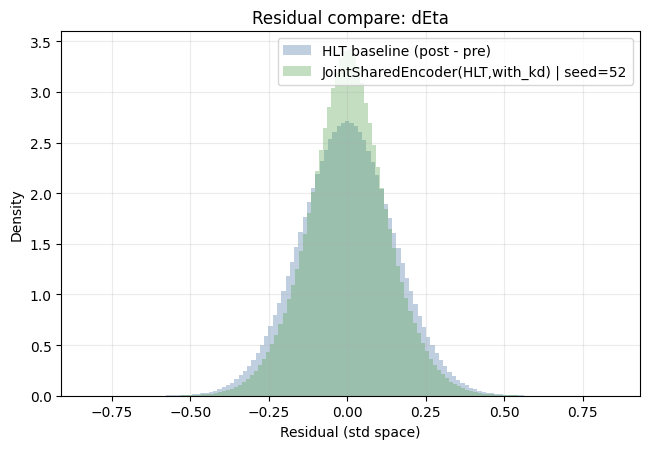

Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_reco_residual_compare_best_dPhi.png


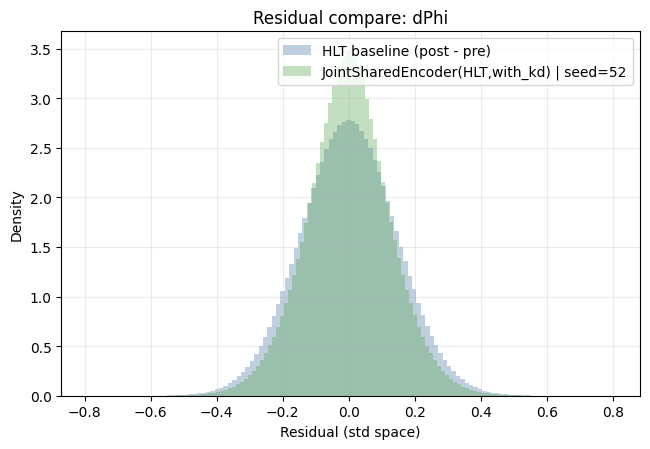

Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_reco_residual_compare_best_log_pt.png


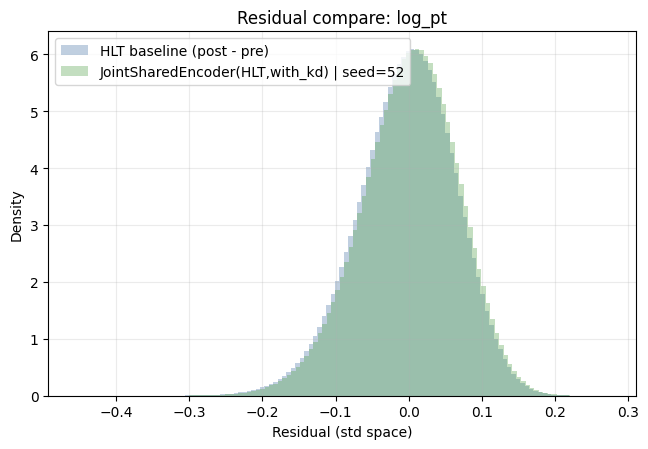

Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_reco_residual_compare_best_log_E.png


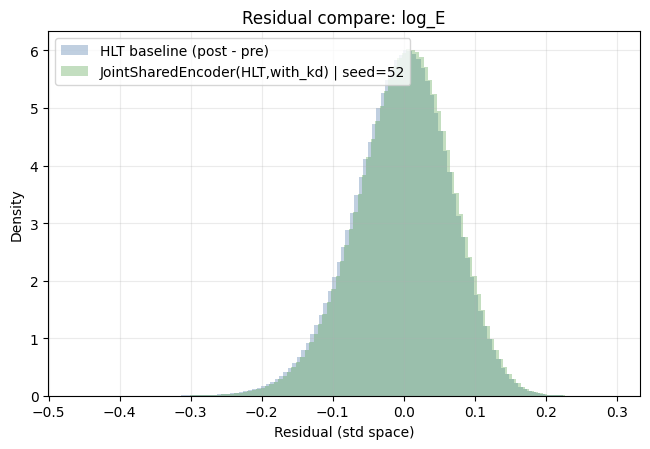

Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_reco_residual_compare_best_log_pt_rel.png


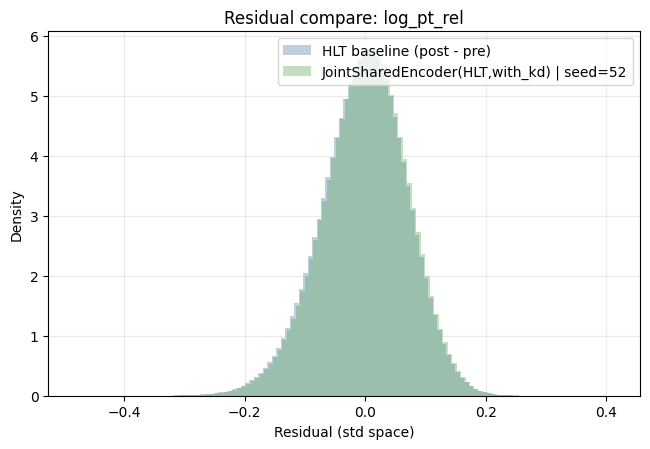

Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_reco_residual_compare_best_log_E_rel.png


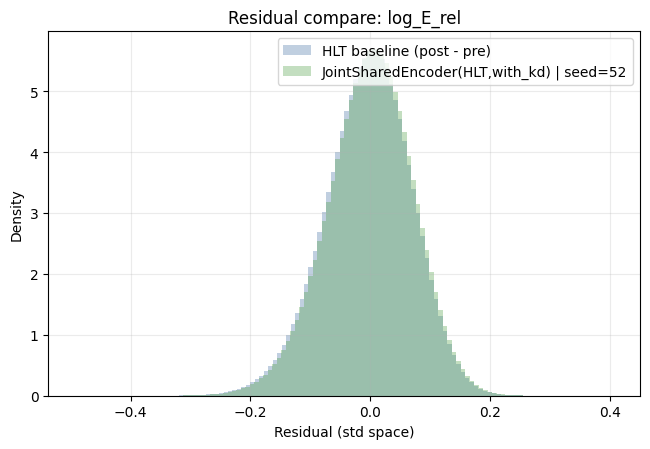

Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_reco_residual_compare_best_dR.png


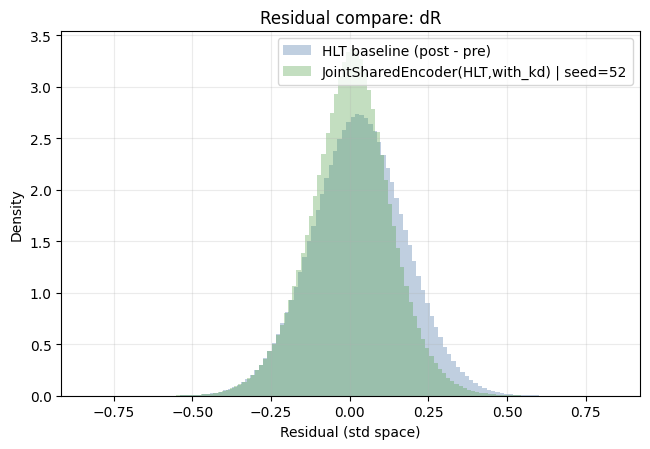


Metrics summary (std space) | split=test | best_joint=JointSharedEncoder(HLT,with_kd) | repeat_seed=52
   feature     method                      best_model  best_repeat_seed      bias      mae     rmse  abs_p50  abs_p90  abs_p99
      dEta        hlt                             hlt               NaN -0.000184 0.118255 0.148565 0.099565 0.244386 0.385240
      dEta best_joint JointSharedEncoder(HLT,with_kd)         52.000000  0.002129 0.100534 0.129121 0.081343 0.213660 0.353102
      dPhi        hlt                             hlt               NaN -0.000084 0.115229 0.144751 0.097069 0.238030 0.375377
      dPhi best_joint JointSharedEncoder(HLT,with_kd)         52.000000 -0.000338 0.098347 0.126243 0.079684 0.208771 0.344930
    log_pt        hlt                             hlt               NaN -0.003350 0.052911 0.066809 0.044398 0.108879 0.177787
    log_pt best_joint JointSharedEncoder(HLT,with_kd)         52.000000  0.001017 0.052803 0.066449 0.044539 0.108392 0.174594
     lo

,feature,method,best_model,best_repeat_seed,bias,mae,rmse,abs_p50,abs_p90,abs_p99
0,dEta,hlt,hlt,NaN,-0.000184,0.118255,0.148565,0.099565,0.244386,0.385240
1,dEta,best_joint,"JointSharedEncoder(HLT,with_kd)",52.0,0.002129,0.100534,0.129121,0.081343,0.213660,0.353102
2,dPhi,hlt,hlt,NaN,-0.000084,0.115229,0.144751,0.097069,0.238030,0.375377
3,dPhi,best_joint,"JointSharedEncoder(HLT,with_kd)",52.0,-0.000338,0.098347,0.126243,0.079684,0.208771,0.344930
4,log_pt,hlt,hlt,NaN,-0.003350,0.052911,0.066809,0.044398,0.108879,0.177787
5,log_pt,best_joint,"JointSharedEncoder(HLT,with_kd)",52.0,0.001017,0.052803,0.066449,0.044539,0.108392,0.174594
6,log_E,hlt,hlt,NaN,-0.003772,0.053630,0.067717,0.044976,0.110406,0.180123
7,log_E,best_joint,"JointSharedEncoder(HLT,with_kd)",52.0,0.000348,0.053419,0.067249,0.045004,0.109734,0.176926
8,log_pt_rel,hlt,hlt,NaN,-0.002711,0.056139,0.070945,0.046968,0.115912,0.188661
9,log_pt_rel,best_joint,"JointSharedEncoder(HLT,with_kd)",52.0,0.000805,0.055940,0.070542,0.046957,0.115358,0.186065


In [ ]:
# 用测试 AUC 最高的 joint 模型查看特征重建表现。
import pandas as pd


@torch.no_grad()
def predict_joint_reco(model, loader):
    model.eval()
    outs = []
    for batch in loader:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        reco, _logits = model(x, m)
        outs.append(reco.detach().cpu().numpy())
    return np.concatenate(outs, axis=0)


def metric_dict(res_1d: np.ndarray):
    if res_1d.size == 0:
        return {
            'bias': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'abs_p50': np.nan,
            'abs_p90': np.nan,
            'abs_p99': np.nan,
        }
    abs_r = np.abs(res_1d)
    return {
        'bias': float(np.mean(res_1d)),
        'mae': float(np.mean(abs_r)),
        'rmse': float(np.sqrt(np.mean(res_1d ** 2))),
        'abs_p50': float(np.quantile(abs_r, 0.50)),
        'abs_p90': float(np.quantile(abs_r, 0.90)),
        'abs_p99': float(np.quantile(abs_r, 0.99)),
    }


def maybe_wrap_residual(name: str, feat_idx: int, residual: np.ndarray) -> np.ndarray:
    if name == 'dPhi':
        sc = float(feat_stds[feat_idx])
        return tool.wrap_dphi_np(residual * sc) / sc
    return residual


best_joint_model_name = str(BEST_JOINT_ROW['model'])
best_joint_repeat_seed = int(BEST_JOINT_ROW['repeat_seed'])
best_joint_ckpt = str(BEST_JOINT_ROW['ckpt_path'])

best_joint_model = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
tool.load_checkpoint(best_joint_model, best_joint_ckpt, map_location=device)
best_joint_model.eval()

pred_best_joint_reco = predict_joint_reco(best_joint_model, test_loader_joint)
x_test_std = x_joint[test_idx]
y_test_std = y_joint[test_idx]
mask_test = common_mask[test_idx]

residual_sources = {
    'hlt': x_test_std - y_test_std,
    'best_joint': pred_best_joint_reco - y_test_std,
}
plot_labels = {
    'hlt': 'HLT baseline (post - pre)',
    'best_joint': f"{best_joint_model_name} | seed={best_joint_repeat_seed}",
}
plot_colors = {
    'hlt': '#4C78A8',
    'best_joint': '#54A24B' if 'with_kd' in best_joint_model_name else '#F58518',
}

metrics_rows = []
for feat_idx, feat_name in enumerate(feat_names):
    plt.figure(figsize=(6.6, 4.6))
    for method_name in ['hlt', 'best_joint']:
        residual = residual_sources[method_name][..., feat_idx][mask_test]
        residual = maybe_wrap_residual(feat_name, feat_idx, residual)
        plt.hist(
            residual,
            bins=120,
            density=True,
            alpha=0.35,
            label=plot_labels[method_name],
            color=plot_colors[method_name],
        )
        mm = metric_dict(residual)
        metrics_rows.append({
            'feature': feat_name,
            'method': method_name,
            'best_model': best_joint_model_name if method_name == 'best_joint' else 'hlt',
            'best_repeat_seed': best_joint_repeat_seed if method_name == 'best_joint' else np.nan,
            **mm,
        })

    plt.title(f'Residual compare: {feat_name}')
    plt.xlabel('Residual (std space)')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f'joint_reco_residual_compare_best_{feat_name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[['feature', 'method', 'best_model', 'best_repeat_seed', 'bias', 'mae', 'rmse', 'abs_p50', 'abs_p90', 'abs_p99']]

print()
print('=' * 120)
print(f'Metrics summary (std space) | split=test | best_joint={best_joint_model_name} | repeat_seed={best_joint_repeat_seed}')
print('=' * 120)
print(metrics_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

metrics_out = os.path.join(TABLE_DIR, 'joint_reco_metrics_summary_best_auc_model_test.csv')
metrics_df.to_csv(metrics_out, index=False)
print('Saved table:', metrics_out)

try:
    from IPython.display import display
    display(metrics_df)
except Exception:
    pass


Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_gate_alpha_over_epochs_seed_42.png


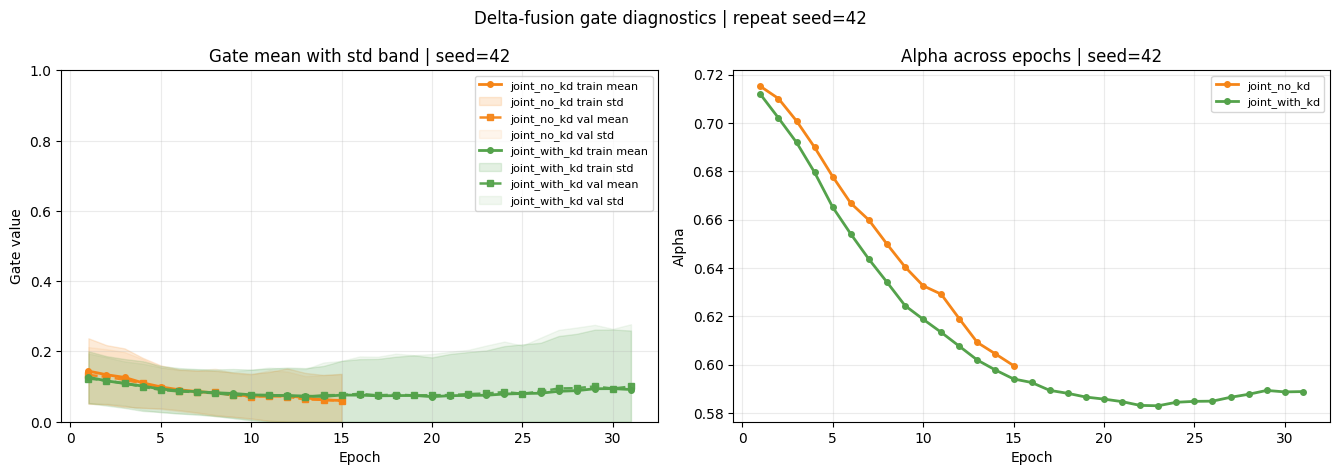

Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_gate_alpha_over_epochs_seed_52.png


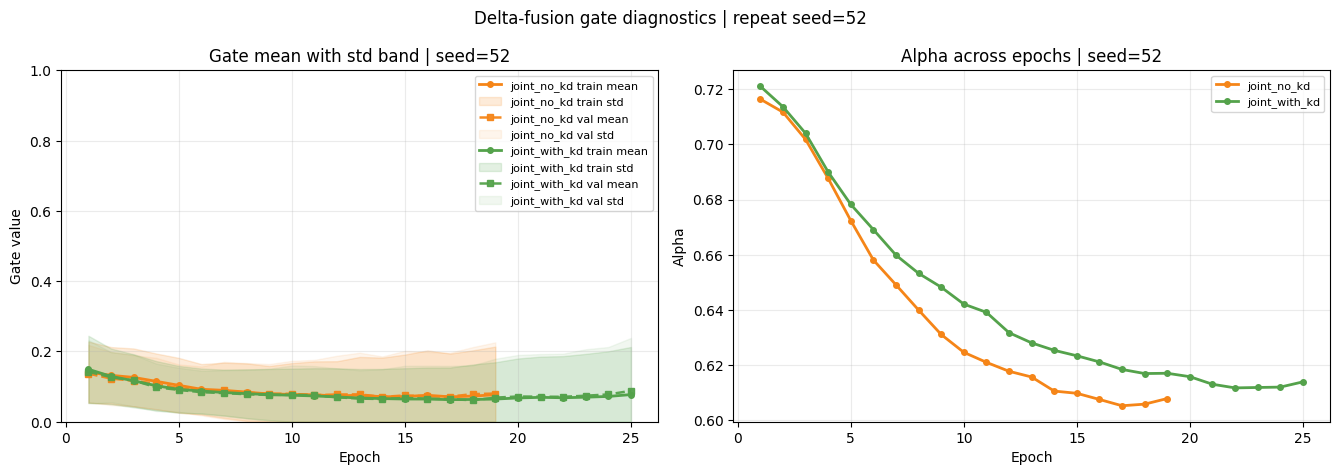

Saved figure: /content/drive/MyDrive/tagging/pure_unsmear/joint_final/runs/unsmear_transformer_sharedencoder_delta_gate_joint_repeat3/figs/joint_gate_alpha_over_epochs_seed_62.png


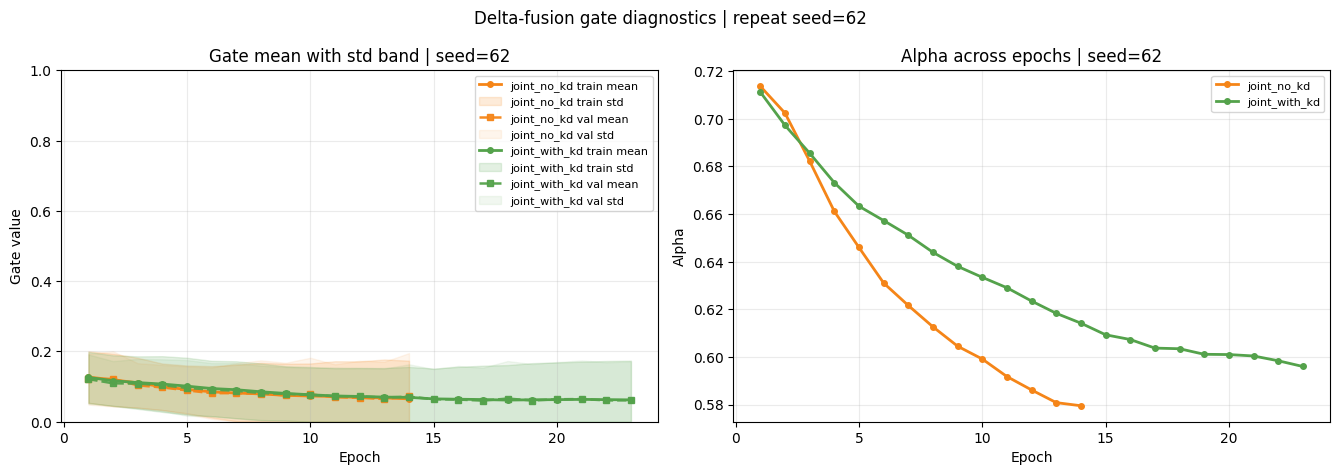

In [ ]:
# 对三次 repeat 分别画 gate / alpha diagnostics。
import pandas as pd

plot_colors = {
    'joint_no_kd': '#F58518',
    'joint_with_kd': '#54A24B',
}

for repeat_result in repeat_results:
    repeat_seed = int(repeat_result['repeat_seed'])
    joint_metric_paths = {
        'joint_no_kd': str(repeat_result['models']['JointSharedEncoder(HLT,no_kd)']['epoch_metrics_path']),
        'joint_with_kd': str(repeat_result['models']['JointSharedEncoder(HLT,with_kd)']['epoch_metrics_path']),
    }

    joint_metric_frames = {}
    for model_name, metric_path in joint_metric_paths.items():
        if not os.path.isfile(metric_path):
            print(f'Missing epoch metrics for {model_name}:', metric_path)
            continue
        df = pd.read_csv(metric_path)
        if 'epoch' not in df.columns:
            print(f'Skip {model_name}: missing epoch column in', metric_path)
            continue
        joint_metric_frames[model_name] = df.sort_values('epoch').reset_index(drop=True)

    if not joint_metric_frames:
        print(f'Skip gate diagnostics for repeat seed={repeat_seed}: no metric tables found.')
        continue

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
    for model_name, df in joint_metric_frames.items():
        x = df['epoch'].to_numpy()
        color = plot_colors.get(model_name, None)

        if {'train_gate_mean', 'train_gate_std'}.issubset(df.columns):
            y = df['train_gate_mean'].to_numpy(dtype=float)
            y_std = df['train_gate_std'].to_numpy(dtype=float)
            axes[0].plot(x, y, marker='o', ms=4, lw=2.0, color=color, label=f'{model_name} train mean')
            axes[0].fill_between(x, np.clip(y - y_std, 0.0, 1.0), np.clip(y + y_std, 0.0, 1.0), color=color, alpha=0.16, label=f'{model_name} train std')

        if {'val_gate_mean', 'val_gate_std'}.issubset(df.columns):
            y = df['val_gate_mean'].to_numpy(dtype=float)
            y_std = df['val_gate_std'].to_numpy(dtype=float)
            axes[0].plot(x, y, marker='s', ms=4, lw=1.8, ls='--', color=color, alpha=0.95, label=f'{model_name} val mean')
            axes[0].fill_between(x, np.clip(y - y_std, 0.0, 1.0), np.clip(y + y_std, 0.0, 1.0), color=color, alpha=0.08, label=f'{model_name} val std')

        if 'alpha' in df.columns:
            axes[1].plot(x, df['alpha'], marker='o', ms=4, lw=2.0, color=color, label=model_name)

    axes[0].set_title(f'Gate mean with std band | seed={repeat_seed}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Gate value')
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].set_title(f'Alpha across epochs | seed={repeat_seed}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Alpha')
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(fontsize=8)

    fig.suptitle(f'Delta-fusion gate diagnostics | repeat seed={repeat_seed}')
    fig.tight_layout()

    gate_diag_out = os.path.join(FIG_DIR, f'joint_gate_alpha_over_epochs_seed_{repeat_seed}.png')
    plt.savefig(gate_diag_out, dpi=170, bbox_inches='tight')
    print('Saved figure:', gate_diag_out)
    plt.show()


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Run name: unsmear_transformer_sharedencoder_delta_gate_joint_repeat3
Repeat dir: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42
Checkpoint path: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42\ckpts\joint_sharedencoder_with_kd.pt
Model: JointSharedEncoder(HLT,with_kd)
Repeat seed: 42
Split: test
Alpha raw: -0.234063
Alpha effective: 0.582948
Ratio mean: 0.086275
Ratio std: 0.046924
Ratio p50: 0.072868
Ratio p90: 0.156643
Ratio p99: 0.238027
Ratio max: 0.286517
Saved rows: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\tables\fusion_ratio_rows_jointsharedencoder_hlt_with_kd_seed_42_test.csv
Saved summary: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\tables\fusion_

,run_name,model,repeat_seed,split,ckpt_path,n_samples,alpha_raw,alpha_effective,ratio_mean,ratio_std,ratio_p50,ratio_p90,ratio_p99,ratio_max,fusion_norm_mean,base_norm_mean,delta_norm_mean,gate_mean_mean,gate_std_mean
0,unsmear_transformer_sharedencoder_delta_gate_j...,"JointSharedEncoder(HLT,with_kd)",42,test,d:\PracticeTagging\tagging\pure_unsmear\joint_...,83334,-0.234063,0.582948,0.086275,0.046924,0.072868,0.156643,0.238027,0.286517,0.99654,11.479238,10.432,0.080268,0.117953


,sample_index,batch_idx,ratio,fusion_norm,base_norm,delta_norm,gate_mean,gate_std,alpha_effective,alpha_raw
0,0,0,0.041710,0.464482,11.135971,10.375219,0.042614,0.059044,0.582948,-0.234063
1,1,0,0.055012,0.615664,11.191515,10.536910,0.048069,0.066661,0.582948,-0.234063
2,2,0,0.056815,0.645922,11.368804,10.294796,0.049282,0.095964,0.582948,-0.234063
3,3,0,0.086811,1.010754,11.643171,10.284449,0.073043,0.130775,0.582948,-0.234063
4,4,0,0.126838,1.479192,11.662106,10.502934,0.072371,0.103429,0.582948,-0.234063


Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\figs\fusion_ratio_hist_jointsharedencoder_hlt_with_kd_seed_42_test.png


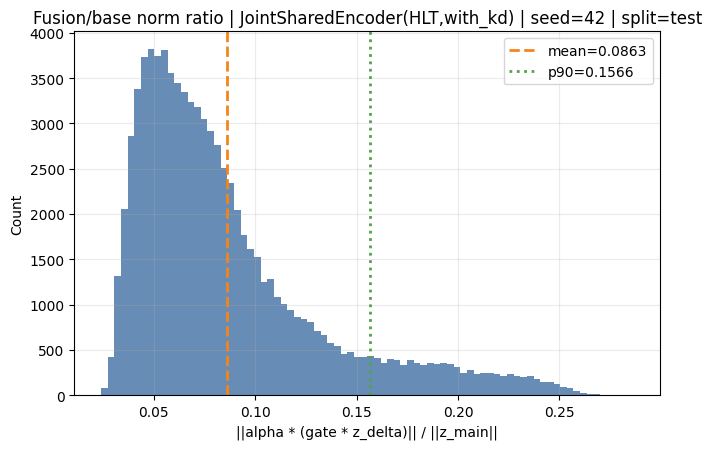

In [7]:
# 从 runs 里的 checkpoint 读取 joint 模型，并统计 ||alpha * (gate * z_delta)|| / ||z_main||。
# 这里用 z_main 对应图里的 h_base，用 z_delta 对应经过 phi(h_dec) 后的融合分支摘要。
# 这个 cell 只依赖前面的数据准备 / 配置 cell，不依赖训练或汇总分析 cell。

import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

TARGET_MODEL = 'JointSharedEncoder(HLT,with_kd)'  # 可选: 'JointSharedEncoder(HLT,no_kd)' / 'JointSharedEncoder(HLT,with_kd)'
TARGET_REPEAT_SEED = 42
TARGET_SPLIT = 'test'  # 可选: 'train' / 'val' / 'test'
TARGET_BATCH_SIZE = int(CONFIG['training'].get('batch_size', 256))
TARGET_RUN_NAME = str(globals().get('RUN_NAME', 'unsmear_transformer_sharedencoder_delta_gate_joint_repeat3'))

valid_models = {
    'JointSharedEncoder(HLT,no_kd)',
    'JointSharedEncoder(HLT,with_kd)',
}
if TARGET_MODEL not in valid_models:
    raise ValueError(f'Unsupported TARGET_MODEL: {TARGET_MODEL}')
if TARGET_SPLIT not in {'train', 'val', 'test'}:
    raise ValueError(f'Unsupported TARGET_SPLIT: {TARGET_SPLIT}')

run_dir = Path(REPEAT_DIR)
if run_dir.name != 'repeats':
    run_dir = Path(MODULE_DIR) / 'runs' / TARGET_RUN_NAME / 'repeats'
if not run_dir.is_dir():
    raise FileNotFoundError(f'Repeat directory not found: {run_dir}')

repeat_candidates = sorted([p for p in run_dir.iterdir() if p.is_dir() and p.name.endswith(f'_seed_{int(TARGET_REPEAT_SEED)}')])
if not repeat_candidates:
    raise FileNotFoundError(f'No repeat folder found for seed={int(TARGET_REPEAT_SEED)} under {run_dir}')
if len(repeat_candidates) > 1:
    print('Multiple repeat folders matched this seed; use the latest one:', repeat_candidates[-1])
repeat_dir = repeat_candidates[-1]
repeat_ckpt_dir = repeat_dir / 'ckpts'

model_to_ckpt_name = {
    'JointSharedEncoder(HLT,no_kd)': 'joint_sharedencoder_no_kd.pt',
    'JointSharedEncoder(HLT,with_kd)': 'joint_sharedencoder_with_kd.pt',
}
ckpt_path = repeat_ckpt_dir / model_to_ckpt_name[TARGET_MODEL]
if not ckpt_path.is_file():
    raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

split_to_idx = {
    'train': train_idx,
    'val': val_idx,
    'test': test_idx,
}
sel_idx = split_to_idx[TARGET_SPLIT]
analysis_ds = tool.JointJetDataset(
    x_joint[sel_idx],
    y_joint[sel_idx],
    common_mask[sel_idx],
    labels[sel_idx],
    weights[sel_idx],
)
analysis_loader = DataLoader(analysis_ds, batch_size=TARGET_BATCH_SIZE, shuffle=False)

analysis_model = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
tool.load_checkpoint(analysis_model, str(ckpt_path), map_location=device)
analysis_model.eval()

@torch.no_grad()
def collect_fusion_ratio_rows(model, loader):
    rows = []
    sample_offset = 0
    effective_alpha = float(model.get_fusion_alpha().detach().cpu().item()) if hasattr(model, 'get_fusion_alpha') else float('nan')
    raw_alpha = float(model.cls_alpha.detach().cpu().item()) if hasattr(model, 'cls_alpha') else float('nan')

    for batch_idx, batch in enumerate(loader):
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        _, _, aux = model(x, m, return_aux=True)

        z_main = aux['z_main']
        z_delta = aux['z_delta']
        gate = aux['gate']
        alpha = aux['alpha'].to(dtype=z_main.dtype)
        fusion_term = alpha * gate * z_delta

        fusion_norm = torch.linalg.norm(fusion_term, dim=-1)
        base_norm = torch.linalg.norm(z_main, dim=-1).clamp_min(1e-12)
        delta_norm = torch.linalg.norm(z_delta, dim=-1)
        gate_mean = gate.mean(dim=-1)
        gate_std = gate.std(dim=-1, unbiased=False)
        ratio = fusion_norm / base_norm

        fusion_np = fusion_norm.detach().cpu().numpy()
        base_np = base_norm.detach().cpu().numpy()
        delta_np = delta_norm.detach().cpu().numpy()
        gate_mean_np = gate_mean.detach().cpu().numpy()
        gate_std_np = gate_std.detach().cpu().numpy()
        ratio_np = ratio.detach().cpu().numpy()

        for i in range(ratio_np.shape[0]):
            rows.append({
                'sample_index': int(sample_offset + i),
                'batch_idx': int(batch_idx),
                'ratio': float(ratio_np[i]),
                'fusion_norm': float(fusion_np[i]),
                'base_norm': float(base_np[i]),
                'delta_norm': float(delta_np[i]),
                'gate_mean': float(gate_mean_np[i]),
                'gate_std': float(gate_std_np[i]),
                'alpha_effective': float(effective_alpha),
                'alpha_raw': float(raw_alpha),
            })
        sample_offset += int(ratio_np.shape[0])
    return pd.DataFrame(rows)

ratio_df = collect_fusion_ratio_rows(analysis_model, analysis_loader)
if ratio_df.empty:
    raise RuntimeError('No ratio rows were collected.')

summary_row = {
    'run_name': str(TARGET_RUN_NAME),
    'model': str(TARGET_MODEL),
    'repeat_seed': int(TARGET_REPEAT_SEED),
    'split': str(TARGET_SPLIT),
    'ckpt_path': str(ckpt_path),
    'n_samples': int(len(ratio_df)),
    'alpha_raw': float(ratio_df['alpha_raw'].iloc[0]),
    'alpha_effective': float(ratio_df['alpha_effective'].iloc[0]),
    'ratio_mean': float(ratio_df['ratio'].mean()),
    'ratio_std': float(ratio_df['ratio'].std(ddof=0)),
    'ratio_p50': float(ratio_df['ratio'].quantile(0.50)),
    'ratio_p90': float(ratio_df['ratio'].quantile(0.90)),
    'ratio_p99': float(ratio_df['ratio'].quantile(0.99)),
    'ratio_max': float(ratio_df['ratio'].max()),
    'fusion_norm_mean': float(ratio_df['fusion_norm'].mean()),
    'base_norm_mean': float(ratio_df['base_norm'].mean()),
    'delta_norm_mean': float(ratio_df['delta_norm'].mean()),
    'gate_mean_mean': float(ratio_df['gate_mean'].mean()),
    'gate_std_mean': float(ratio_df['gate_std'].mean()),
}
summary_df = pd.DataFrame([summary_row])

safe_model_tag = re.sub(r'[^0-9A-Za-z]+', '_', str(TARGET_MODEL)).strip('_').lower()
ratio_csv_out = os.path.join(TABLE_DIR, f'fusion_ratio_rows_{safe_model_tag}_seed_{int(TARGET_REPEAT_SEED)}_{TARGET_SPLIT}.csv')
summary_csv_out = os.path.join(TABLE_DIR, f'fusion_ratio_summary_{safe_model_tag}_seed_{int(TARGET_REPEAT_SEED)}_{TARGET_SPLIT}.csv')
ratio_df.to_csv(ratio_csv_out, index=False)
summary_df.to_csv(summary_csv_out, index=False)

print('Run name:', TARGET_RUN_NAME)
print('Repeat dir:', repeat_dir)
print('Checkpoint path:', ckpt_path)
print('Model:', TARGET_MODEL)
print('Repeat seed:', int(TARGET_REPEAT_SEED))
print('Split:', TARGET_SPLIT)
print('Alpha raw:', f"{summary_row['alpha_raw']:.6f}")
print('Alpha effective:', f"{summary_row['alpha_effective']:.6f}")
print('Ratio mean:', f"{summary_row['ratio_mean']:.6f}")
print('Ratio std:', f"{summary_row['ratio_std']:.6f}")
print('Ratio p50:', f"{summary_row['ratio_p50']:.6f}")
print('Ratio p90:', f"{summary_row['ratio_p90']:.6f}")
print('Ratio p99:', f"{summary_row['ratio_p99']:.6f}")
print('Ratio max:', f"{summary_row['ratio_max']:.6f}")
print('Saved rows:', ratio_csv_out)
print('Saved summary:', summary_csv_out)

display(summary_df)
display(ratio_df.head())

plt.figure(figsize=(6.8, 4.6))
plt.hist(ratio_df['ratio'].to_numpy(), bins=80, color='#4C78A8', alpha=0.85)
plt.axvline(summary_row['ratio_mean'], color='#F58518', ls='--', lw=2.0, label=f"mean={summary_row['ratio_mean']:.4f}")
plt.axvline(summary_row['ratio_p90'], color='#54A24B', ls=':', lw=2.0, label=f"p90={summary_row['ratio_p90']:.4f}")
plt.xlabel(r'||alpha * (gate * z_delta)|| / ||z_main||')
plt.ylabel('Count')
plt.title(f'Fusion/base norm ratio | {TARGET_MODEL} | seed={int(TARGET_REPEAT_SEED)} | split={TARGET_SPLIT}')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
ratio_fig_out = os.path.join(FIG_DIR, f'fusion_ratio_hist_{safe_model_tag}_seed_{int(TARGET_REPEAT_SEED)}_{TARGET_SPLIT}.png')
plt.savefig(ratio_fig_out, dpi=160, bbox_inches='tight')
print('Saved figure:', ratio_fig_out)
plt.show()

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Run name: unsmear_transformer_sharedencoder_delta_gate_joint_repeat3
Repeat dir: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42
Teacher checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42\ckpts\teacher_offline.pt
Joint no_kd checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42\ckpts\joint_sharedencoder_no_kd.pt
Joint with_kd checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42\ckpts\joint_sharedencoder_with_kd.pt
Split: test

Closer to offline teacher embedding means smaller distance.
Best method by mean distance: Joint with_kd reco

Distance summary:
            method  distance_mean  distance

,method,distance_mean,distance_weighted_mean,distance_p50,distance_p90,distance_p99,distance_max
0,Joint with_kd reco,0.211582,0.255791,0.023257,0.589089,2.841137,4.030005
1,Joint no_kd reco,0.214718,0.263317,0.026512,0.603315,2.766247,4.028481
2,HLT input,0.385008,0.600979,0.072316,1.234021,3.492019,4.030157


,method,delta_mean_vs_hlt,delta_p50_vs_hlt,delta_p90_vs_hlt,fraction_better_than_hlt,fraction_worse_than_hlt
0,Joint with_kd reco,0.173426,0.014572,0.993609,0.657943,0.342057
1,Joint no_kd reco,0.170290,0.013707,0.971407,0.652891,0.347109


,sample_index,batch_idx,method,teacher_embedding_distance,weight,label
0,0,0,hlt_input,1.111645,1.476280,0.0
1,1,0,hlt_input,0.923156,1.000000,1.0
2,2,0,hlt_input,0.244534,1.000000,1.0
3,3,0,hlt_input,0.006102,1.000000,1.0
4,4,0,hlt_input,0.020733,0.275464,0.0


Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\figs\teacher_embedding_distance_compare_seed_42_test.png


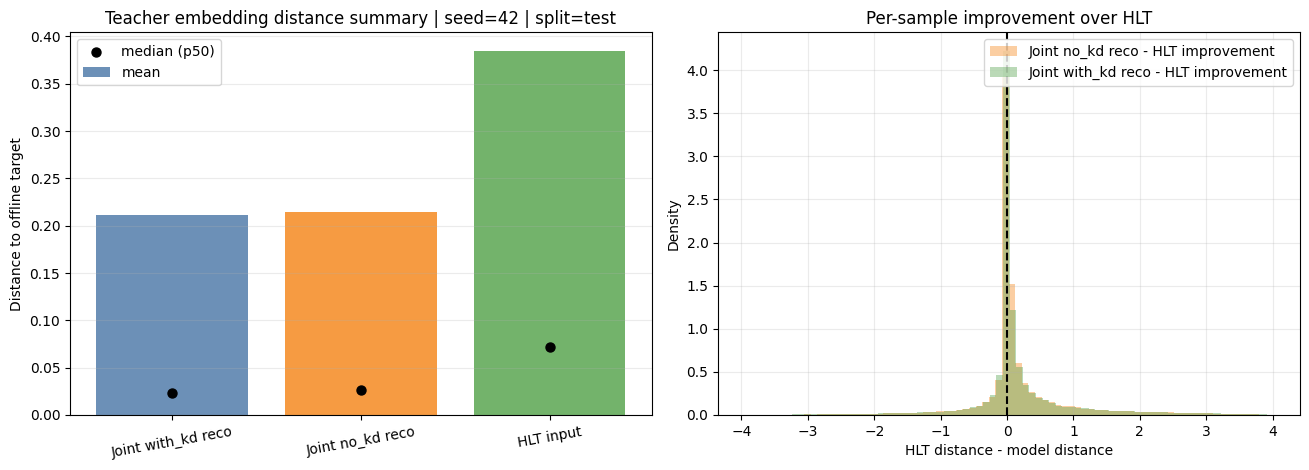

In [9]:
# 比较 HLT 输入和两个 joint 模型重建结果，相对 offline target 的 teacher embedding distance。
# 这个 cell 只依赖前面的数据读取 / 配置 / dataset cell，不依赖训练汇总 cell。

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

TARGET_REPEAT_SEED = 42
TARGET_SPLIT = 'test'  # 可选: 'train' / 'val' / 'test'
TARGET_BATCH_SIZE = int(CONFIG['training'].get('batch_size', 256))
TARGET_RUN_NAME = str(globals().get('RUN_NAME', 'unsmear_transformer_sharedencoder_delta_gate_joint_repeat3'))

if TARGET_SPLIT not in {'train', 'val', 'test'}:
    raise ValueError(f'Unsupported TARGET_SPLIT: {TARGET_SPLIT}')

run_dir = Path(REPEAT_DIR)
if run_dir.name != 'repeats':
    run_dir = Path(MODULE_DIR) / 'runs' / TARGET_RUN_NAME / 'repeats'
if not run_dir.is_dir():
    raise FileNotFoundError(f'Repeat directory not found: {run_dir}')

repeat_candidates = sorted([p for p in run_dir.iterdir() if p.is_dir() and p.name.endswith(f'_seed_{int(TARGET_REPEAT_SEED)}')])
if not repeat_candidates:
    raise FileNotFoundError(f'No repeat folder found for seed={int(TARGET_REPEAT_SEED)} under {run_dir}')
if len(repeat_candidates) > 1:
    print('Multiple repeat folders matched this seed; use the latest one:', repeat_candidates[-1])
repeat_dir = repeat_candidates[-1]
repeat_ckpt_dir = repeat_dir / 'ckpts'

teacher_ckpt = repeat_ckpt_dir / 'teacher_offline.pt'
joint_no_kd_ckpt = repeat_ckpt_dir / 'joint_sharedencoder_no_kd.pt'
joint_with_kd_ckpt = repeat_ckpt_dir / 'joint_sharedencoder_with_kd.pt'
for required_path in [teacher_ckpt, joint_no_kd_ckpt, joint_with_kd_ckpt]:
    if not required_path.is_file():
        raise FileNotFoundError(f'Checkpoint not found: {required_path}')

split_to_idx = {
    'train': train_idx,
    'val': val_idx,
    'test': test_idx,
}
sel_idx = split_to_idx[TARGET_SPLIT]
analysis_ds = tool.JointJetDataset(
    x_joint[sel_idx],
    y_joint[sel_idx],
    common_mask[sel_idx],
    labels[sel_idx],
    weights[sel_idx],
)
analysis_loader = DataLoader(analysis_ds, batch_size=TARGET_BATCH_SIZE, shuffle=False)

teacher_model = ParticleTransformerKD(**CONFIG['tagger']).to(device)
tool.load_checkpoint(teacher_model, str(teacher_ckpt), map_location=device)
teacher_model.eval()

joint_no_kd_model = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
tool.load_checkpoint(joint_no_kd_model, str(joint_no_kd_ckpt), map_location=device)
joint_no_kd_model.eval()

joint_with_kd_model = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
tool.load_checkpoint(joint_with_kd_model, str(joint_with_kd_ckpt), map_location=device)
joint_with_kd_model.eval()

@torch.no_grad()
def extract_teacher_embedding(model, x, mask):
    B, S, _ = x.shape
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    h = x.reshape(B * S, model.input_dim)
    h = model.input_proj(h)
    h = h.reshape(B, S, model.embed_dim)
    h = model.transformer(h, src_key_padding_mask=~mask)
    q = model.pool_query.expand(B, -1, -1)
    pooled, _ = model.pool_attn(q, h, h, key_padding_mask=~mask, need_weights=False)
    z = model.norm(pooled.squeeze(1))
    return z


def per_sample_embedding_mse(candidate_z, target_z):
    return torch.mean((candidate_z - target_z) ** 2, dim=-1)


@torch.no_grad()
def collect_embedding_distance_rows(teacher, joint_no_kd, joint_with_kd, loader):
    rows = []
    sample_offset = 0
    for batch_idx, batch in enumerate(loader):
        x = batch['x'].to(device)
        y_off = batch['y_unsmear'].to(device)
        m = batch['mask'].to(device)
        w = batch['weight'].to(device)
        y_cls = batch['label'].to(device)

        target_z = extract_teacher_embedding(teacher, y_off, m)
        hlt_z = extract_teacher_embedding(teacher, x, m)

        reco_no_kd, _ = joint_no_kd(x, m)
        reco_with_kd, _ = joint_with_kd(x, m)
        reco_no_kd_z = extract_teacher_embedding(teacher, reco_no_kd, m)
        reco_with_kd_z = extract_teacher_embedding(teacher, reco_with_kd, m)

        per_method = {
            'hlt_input': per_sample_embedding_mse(hlt_z, target_z),
            'joint_no_kd_reco': per_sample_embedding_mse(reco_no_kd_z, target_z),
            'joint_with_kd_reco': per_sample_embedding_mse(reco_with_kd_z, target_z),
        }

        weight_np = w.detach().cpu().numpy()
        label_np = y_cls.detach().cpu().numpy()
        for method_name, dist_tensor in per_method.items():
            dist_np = dist_tensor.detach().cpu().numpy()
            for i in range(dist_np.shape[0]):
                rows.append({
                    'sample_index': int(sample_offset + i),
                    'batch_idx': int(batch_idx),
                    'method': str(method_name),
                    'teacher_embedding_distance': float(dist_np[i]),
                    'weight': float(weight_np[i]),
                    'label': float(label_np[i]),
                })
        sample_offset += int(x.shape[0])
    return pd.DataFrame(rows)


distance_df = collect_embedding_distance_rows(
    teacher_model,
    joint_no_kd_model,
    joint_with_kd_model,
    analysis_loader,
)
if distance_df.empty:
    raise RuntimeError('No teacher embedding distance rows were collected.')

summary_rows = []
for method_name, df_method in distance_df.groupby('method', sort=False):
    values = df_method['teacher_embedding_distance'].to_numpy(dtype=np.float64)
    weights_np = df_method['weight'].to_numpy(dtype=np.float64)
    weighted_mean = float(np.average(values, weights=weights_np)) if np.sum(weights_np) > 0 else float(np.mean(values))
    summary_rows.append({
        'run_name': str(TARGET_RUN_NAME),
        'repeat_seed': int(TARGET_REPEAT_SEED),
        'split': str(TARGET_SPLIT),
        'method': str(method_name),
        'n_samples': int(len(df_method)),
        'distance_mean': float(np.mean(values)),
        'distance_std': float(np.std(values, ddof=0)),
        'distance_weighted_mean': weighted_mean,
        'distance_p50': float(np.quantile(values, 0.50)),
        'distance_p90': float(np.quantile(values, 0.90)),
        'distance_p99': float(np.quantile(values, 0.99)),
        'distance_max': float(np.max(values)),
    })
summary_df = pd.DataFrame(summary_rows)

method_order = ['hlt_input', 'joint_no_kd_reco', 'joint_with_kd_reco']
summary_df['method'] = pd.Categorical(summary_df['method'], categories=method_order, ordered=True)
summary_df = summary_df.sort_values('method').reset_index(drop=True)

display_name_map = {
    'hlt_input': 'HLT input',
    'joint_no_kd_reco': 'Joint no_kd reco',
    'joint_with_kd_reco': 'Joint with_kd reco',
}
plot_color_map = {
    'hlt_input': '#4C78A8',
    'joint_no_kd_reco': '#F58518',
    'joint_with_kd_reco': '#54A24B',
}

pivot_df = distance_df.pivot(index='sample_index', columns='method', values='teacher_embedding_distance').reset_index()
required_methods = ['hlt_input', 'joint_no_kd_reco', 'joint_with_kd_reco']
missing_methods = [m for m in required_methods if m not in pivot_df.columns]
if missing_methods:
    raise RuntimeError(f'Missing methods in pivot table: {missing_methods}')

improve_rows = []
for method_name in ['joint_no_kd_reco', 'joint_with_kd_reco']:
    improvement = pivot_df['hlt_input'].to_numpy(dtype=np.float64) - pivot_df[method_name].to_numpy(dtype=np.float64)
    improve_rows.append({
        'method': method_name,
        'delta_mean_vs_hlt': float(np.mean(improvement)),
        'delta_p50_vs_hlt': float(np.quantile(improvement, 0.50)),
        'delta_p90_vs_hlt': float(np.quantile(improvement, 0.90)),
        'fraction_better_than_hlt': float(np.mean(improvement > 0.0)),
        'fraction_worse_than_hlt': float(np.mean(improvement < 0.0)),
    })
improve_df = pd.DataFrame(improve_rows)

summary_view = summary_df.copy()
summary_view['method'] = summary_view['method'].map(display_name_map)
summary_view = summary_view[['method', 'distance_mean', 'distance_weighted_mean', 'distance_p50', 'distance_p90', 'distance_p99', 'distance_max']]
summary_view = summary_view.sort_values('distance_mean', ascending=True).reset_index(drop=True)

improve_view = improve_df.copy()
improve_view['method'] = improve_view['method'].map(display_name_map)
improve_view = improve_view.sort_values('delta_mean_vs_hlt', ascending=False).reset_index(drop=True)

safe_split = str(TARGET_SPLIT)
rows_out = os.path.join(TABLE_DIR, f'teacher_embedding_distance_rows_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.csv')
summary_out = os.path.join(TABLE_DIR, f'teacher_embedding_distance_summary_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.csv')
improve_out = os.path.join(TABLE_DIR, f'teacher_embedding_distance_improvement_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.csv')
distance_df.to_csv(rows_out, index=False)
summary_df.to_csv(summary_out, index=False)
improve_df.to_csv(improve_out, index=False)

best_method = str(summary_view.iloc[0]['method'])
print('Run name:', TARGET_RUN_NAME)
print('Repeat dir:', repeat_dir)
print('Teacher checkpoint:', teacher_ckpt)
print('Joint no_kd checkpoint:', joint_no_kd_ckpt)
print('Joint with_kd checkpoint:', joint_with_kd_ckpt)
print('Split:', TARGET_SPLIT)
print()
print('Closer to offline teacher embedding means smaller distance.')
print('Best method by mean distance:', best_method)
print()
print('Distance summary:')
print(summary_view.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print()
print('Improvement over HLT (positive means better than HLT):')
print(improve_view.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print()
print('Saved rows:', rows_out)
print('Saved summary:', summary_out)
print('Saved improvement:', improve_out)

display(summary_view)
display(improve_view)
display(distance_df.head())

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

bar_methods = summary_view['method'].tolist()
bar_means = summary_view['distance_mean'].to_numpy(dtype=float)
bar_medians = summary_view['distance_p50'].to_numpy(dtype=float)
bar_colors = [plot_color_map[k] for k in ['hlt_input', 'joint_no_kd_reco', 'joint_with_kd_reco'] if display_name_map[k] in bar_methods]
axes[0].bar(bar_methods, bar_means, color=bar_colors, alpha=0.82, label='mean')
axes[0].scatter(bar_methods, bar_medians, color='black', s=42, zorder=3, label='median (p50)')
axes[0].set_title(f'Teacher embedding distance summary | seed={int(TARGET_REPEAT_SEED)} | split={TARGET_SPLIT}')
axes[0].set_ylabel('Distance to offline target')
axes[0].grid(True, axis='y', alpha=0.25)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=10)

for method_name in ['joint_no_kd_reco', 'joint_with_kd_reco']:
    improvement = pivot_df['hlt_input'].to_numpy(dtype=np.float64) - pivot_df[method_name].to_numpy(dtype=np.float64)
    axes[1].hist(
        improvement,
        bins=80,
        alpha=0.40,
        density=True,
        label=f"{display_name_map[method_name]} - HLT improvement",
        color=plot_color_map[method_name],
    )
axes[1].axvline(0.0, color='black', ls='--', lw=1.5)
axes[1].set_title('Per-sample improvement over HLT')
axes[1].set_xlabel('HLT distance - model distance')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.25)
axes[1].legend()

fig.tight_layout()
fig_out = os.path.join(FIG_DIR, f'teacher_embedding_distance_compare_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.png')
plt.savefig(fig_out, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_out)
plt.show()

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Run name: unsmear_transformer_sharedencoder_delta_gate_joint_repeat3
Repeat dir: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42
Teacher checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42\ckpts\teacher_offline.pt
HLT checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42\ckpts\student_hlt.pt
Joint no_kd checkpoint: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42\ckpts\joint_sharedencoder_no_kd.pt
Split: test

All case counts within teacher-correct samples:
case_group
Both correct                 66252
Both wrong                    3202
HLT correct / Joint wrong     2277
HLT wrong / Joint correct     160

,case_group,n_samples,hlt_mean_distance,joint_mean_distance,hlt_weighted_mean_distance,joint_weighted_mean_distance,hlt_p50_distance,joint_p50_distance,improvement_mean,improvement_p50,fraction_joint_closer_than_hlt
0,HLT wrong / Joint correct,1608,0.572630,0.572028,0.860856,0.597801,0.174814,0.137312,0.000602,0.007062,0.545398
1,HLT correct / Joint wrong,2277,0.633027,0.419537,0.959858,0.498004,0.193227,0.087911,0.213491,0.037234,0.631972
2,Both wrong,3202,0.967872,1.082761,1.408817,1.118347,0.372979,0.629481,-0.114889,-0.000304,0.497814


,sample_index,batch_idx,label,weight,teacher_pred,hlt_pred,joint_no_kd_pred,teacher_correct,hlt_correct,joint_no_kd_correct,case_group,hlt_teacher_embedding_distance,joint_no_kd_teacher_embedding_distance,distance_improvement_vs_hlt
0,0,0,0,1.476280,0,0,1,True,True,False,hlt_correct_joint_wrong,1.111645,0.154258,0.957387
1,1,0,1,1.000000,1,0,1,True,False,True,hlt_wrong_joint_correct,0.923156,3.660449,-2.737293
9,13,0,1,1.000000,1,0,0,True,False,False,both_wrong,0.595784,3.336316,-2.740532
11,15,0,1,1.000000,1,0,1,True,False,True,hlt_wrong_joint_correct,0.039593,0.002860,0.036732
18,23,0,0,1.505889,0,1,1,True,False,False,both_wrong,1.088678,0.065427,1.023251


Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\figs\teacher_embedding_error_case_compare_seed_42_test.png


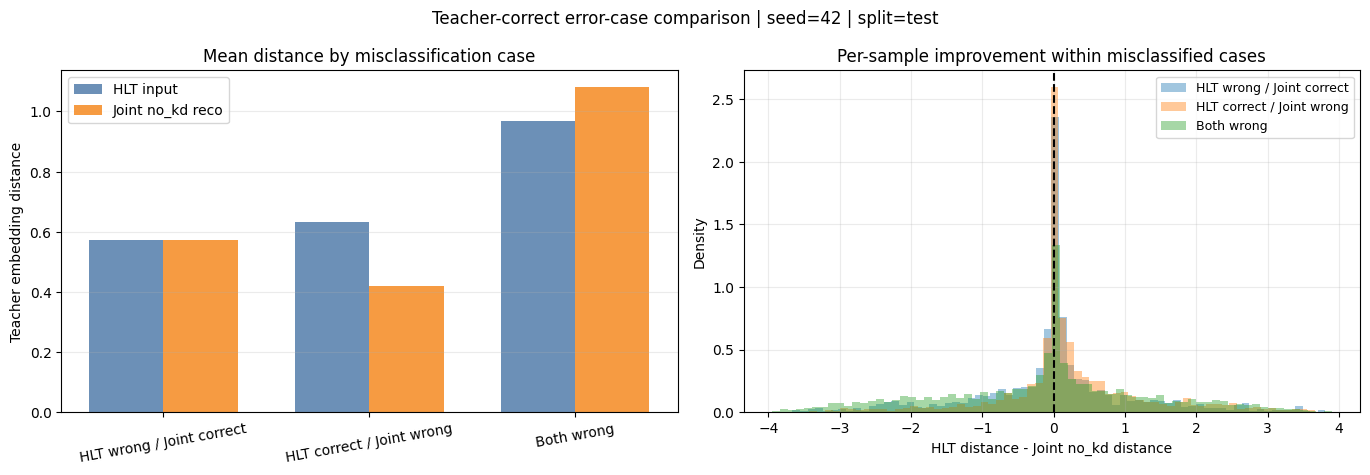

In [10]:
# 分析 offline teacher 分类正确时，HLT baseline 与 joint_no_kd 的错判案例，
# 并比较这些案例在 teacher embedding distance 上的差异。
# 这个 cell 只依赖前面的数据读取 / 配置 / dataset cell，不依赖训练汇总 cell。

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

TARGET_REPEAT_SEED = 42
TARGET_SPLIT = 'test'  # 可选: 'train' / 'val' / 'test'
TARGET_BATCH_SIZE = int(CONFIG['training'].get('batch_size', 256))
TARGET_RUN_NAME = str(globals().get('RUN_NAME', 'unsmear_transformer_sharedencoder_delta_gate_joint_repeat3'))

if TARGET_SPLIT not in {'train', 'val', 'test'}:
    raise ValueError(f'Unsupported TARGET_SPLIT: {TARGET_SPLIT}')

run_dir = Path(REPEAT_DIR)
if run_dir.name != 'repeats':
    run_dir = Path(MODULE_DIR) / 'runs' / TARGET_RUN_NAME / 'repeats'
if not run_dir.is_dir():
    raise FileNotFoundError(f'Repeat directory not found: {run_dir}')

repeat_candidates = sorted([p for p in run_dir.iterdir() if p.is_dir() and p.name.endswith(f'_seed_{int(TARGET_REPEAT_SEED)}')])
if not repeat_candidates:
    raise FileNotFoundError(f'No repeat folder found for seed={int(TARGET_REPEAT_SEED)} under {run_dir}')
repeat_dir = repeat_candidates[-1]
repeat_ckpt_dir = repeat_dir / 'ckpts'

teacher_ckpt = repeat_ckpt_dir / 'teacher_offline.pt'
hlt_ckpt = repeat_ckpt_dir / 'student_hlt.pt'
joint_no_kd_ckpt = repeat_ckpt_dir / 'joint_sharedencoder_no_kd.pt'
for required_path in [teacher_ckpt, hlt_ckpt, joint_no_kd_ckpt]:
    if not required_path.is_file():
        raise FileNotFoundError(f'Checkpoint not found: {required_path}')

split_to_idx = {
    'train': train_idx,
    'val': val_idx,
    'test': test_idx,
}
sel_idx = split_to_idx[TARGET_SPLIT]
analysis_ds = tool.JointJetDataset(
    x_joint[sel_idx],
    y_joint[sel_idx],
    common_mask[sel_idx],
    labels[sel_idx],
    weights[sel_idx],
)
analysis_loader = DataLoader(analysis_ds, batch_size=TARGET_BATCH_SIZE, shuffle=False)

teacher_model = ParticleTransformerKD(**CONFIG['tagger']).to(device)
tool.load_checkpoint(teacher_model, str(teacher_ckpt), map_location=device)
teacher_model.eval()

hlt_model = ParticleTransformerKD(**CONFIG['tagger']).to(device)
tool.load_checkpoint(hlt_model, str(hlt_ckpt), map_location=device)
hlt_model.eval()

joint_no_kd_model = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
tool.load_checkpoint(joint_no_kd_model, str(joint_no_kd_ckpt), map_location=device)
joint_no_kd_model.eval()

@torch.no_grad()
def extract_teacher_embedding(model, x, mask):
    B, S, _ = x.shape
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    h = x.reshape(B * S, model.input_dim)
    h = model.input_proj(h)
    h = h.reshape(B, S, model.embed_dim)
    h = model.transformer(h, src_key_padding_mask=~mask)
    q = model.pool_query.expand(B, -1, -1)
    pooled, _ = model.pool_attn(q, h, h, key_padding_mask=~mask, need_weights=False)
    z = model.norm(pooled.squeeze(1))
    return z


def per_sample_embedding_mse(candidate_z, target_z):
    return torch.mean((candidate_z - target_z) ** 2, dim=-1)


@torch.no_grad()
def collect_case_rows(teacher, hlt, joint_no_kd, loader):
    rows = []
    sample_offset = 0
    for batch_idx, batch in enumerate(loader):
        x = batch['x'].to(device)
        y_off = batch['y_unsmear'].to(device)
        m = batch['mask'].to(device)
        y_cls = batch['label'].to(device)
        w = batch['weight'].to(device)

        teacher_logits = teacher(y_off, m).squeeze(-1)
        hlt_logits = hlt(x, m).squeeze(-1)
        reco_no_kd, joint_no_kd_logits = joint_no_kd(x, m)
        joint_no_kd_logits = joint_no_kd_logits.squeeze(-1)

        target_z = extract_teacher_embedding(teacher, y_off, m)
        hlt_z = extract_teacher_embedding(teacher, x, m)
        reco_no_kd_z = extract_teacher_embedding(teacher, reco_no_kd, m)

        teacher_pred = (torch.sigmoid(teacher_logits) >= 0.5)
        hlt_pred = (torch.sigmoid(hlt_logits) >= 0.5)
        joint_pred = (torch.sigmoid(joint_no_kd_logits) >= 0.5)
        label_bool = (y_cls >= 0.5)

        teacher_correct = (teacher_pred == label_bool)
        hlt_correct = (hlt_pred == label_bool)
        joint_correct = (joint_pred == label_bool)

        hlt_dist = per_sample_embedding_mse(hlt_z, target_z)
        joint_dist = per_sample_embedding_mse(reco_no_kd_z, target_z)
        dist_improvement = hlt_dist - joint_dist

        teacher_pred_np = teacher_pred.detach().cpu().numpy()
        hlt_pred_np = hlt_pred.detach().cpu().numpy()
        joint_pred_np = joint_pred.detach().cpu().numpy()
        teacher_correct_np = teacher_correct.detach().cpu().numpy()
        hlt_correct_np = hlt_correct.detach().cpu().numpy()
        joint_correct_np = joint_correct.detach().cpu().numpy()
        label_np = label_bool.detach().cpu().numpy()
        weight_np = w.detach().cpu().numpy()
        hlt_dist_np = hlt_dist.detach().cpu().numpy()
        joint_dist_np = joint_dist.detach().cpu().numpy()
        improve_np = dist_improvement.detach().cpu().numpy()

        for i in range(x.shape[0]):
            if (not bool(teacher_correct_np[i])):
                continue
            if bool(hlt_correct_np[i]) and bool(joint_correct_np[i]):
                case_group = 'both_correct'
            elif (not bool(hlt_correct_np[i])) and bool(joint_correct_np[i]):
                case_group = 'hlt_wrong_joint_correct'
            elif bool(hlt_correct_np[i]) and (not bool(joint_correct_np[i])):
                case_group = 'hlt_correct_joint_wrong'
            else:
                case_group = 'both_wrong'
            rows.append({
                'sample_index': int(sample_offset + i),
                'batch_idx': int(batch_idx),
                'label': int(label_np[i]),
                'weight': float(weight_np[i]),
                'teacher_pred': int(teacher_pred_np[i]),
                'hlt_pred': int(hlt_pred_np[i]),
                'joint_no_kd_pred': int(joint_pred_np[i]),
                'teacher_correct': bool(teacher_correct_np[i]),
                'hlt_correct': bool(hlt_correct_np[i]),
                'joint_no_kd_correct': bool(joint_correct_np[i]),
                'case_group': str(case_group),
                'hlt_teacher_embedding_distance': float(hlt_dist_np[i]),
                'joint_no_kd_teacher_embedding_distance': float(joint_dist_np[i]),
                'distance_improvement_vs_hlt': float(improve_np[i]),
            })
        sample_offset += int(x.shape[0])
    return pd.DataFrame(rows)


case_df = collect_case_rows(teacher_model, hlt_model, joint_no_kd_model, analysis_loader)
if case_df.empty:
    raise RuntimeError('No teacher-correct cases were collected.')

focus_order = ['hlt_wrong_joint_correct', 'hlt_correct_joint_wrong', 'both_wrong']
focus_df = case_df[case_df['case_group'].isin(focus_order)].copy()
if focus_df.empty:
    raise RuntimeError('No teacher-correct misclassified cases were found for the selected split.')

summary_rows = []
for case_group in focus_order:
    df_group = focus_df[focus_df['case_group'] == case_group].copy()
    if df_group.empty:
        continue
    hlt_values = df_group['hlt_teacher_embedding_distance'].to_numpy(dtype=np.float64)
    joint_values = df_group['joint_no_kd_teacher_embedding_distance'].to_numpy(dtype=np.float64)
    improve_values = df_group['distance_improvement_vs_hlt'].to_numpy(dtype=np.float64)
    weights_np = df_group['weight'].to_numpy(dtype=np.float64)
    summary_rows.append({
        'case_group': str(case_group),
        'n_samples': int(len(df_group)),
        'hlt_mean_distance': float(np.mean(hlt_values)),
        'joint_mean_distance': float(np.mean(joint_values)),
        'hlt_weighted_mean_distance': float(np.average(hlt_values, weights=weights_np)) if np.sum(weights_np) > 0 else float(np.mean(hlt_values)),
        'joint_weighted_mean_distance': float(np.average(joint_values, weights=weights_np)) if np.sum(weights_np) > 0 else float(np.mean(joint_values)),
        'hlt_p50_distance': float(np.quantile(hlt_values, 0.50)),
        'joint_p50_distance': float(np.quantile(joint_values, 0.50)),
        'improvement_mean': float(np.mean(improve_values)),
        'improvement_p50': float(np.quantile(improve_values, 0.50)),
        'fraction_joint_closer_than_hlt': float(np.mean(improve_values > 0.0)),
    })
summary_df = pd.DataFrame(summary_rows)

group_display_map = {
    'hlt_wrong_joint_correct': 'HLT wrong / Joint correct',
    'hlt_correct_joint_wrong': 'HLT correct / Joint wrong',
    'both_wrong': 'Both wrong',
    'both_correct': 'Both correct',
}
summary_view = summary_df.copy()
summary_view['case_group'] = summary_view['case_group'].map(group_display_map)

safe_split = str(TARGET_SPLIT)
rows_out = os.path.join(TABLE_DIR, f'teacher_embedding_case_rows_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.csv')
summary_out = os.path.join(TABLE_DIR, f'teacher_embedding_case_summary_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.csv')
focus_df.to_csv(rows_out, index=False)
summary_df.to_csv(summary_out, index=False)

print('Run name:', TARGET_RUN_NAME)
print('Repeat dir:', repeat_dir)
print('Teacher checkpoint:', teacher_ckpt)
print('HLT checkpoint:', hlt_ckpt)
print('Joint no_kd checkpoint:', joint_no_kd_ckpt)
print('Split:', TARGET_SPLIT)
print()
print('All case counts within teacher-correct samples:')
print(case_df['case_group'].value_counts().rename(index=group_display_map).to_string())
print()
print('Focused misclassified case summary:')
print(summary_view.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print()
print('Interpretation: smaller distance means closer to offline teacher embedding; positive improvement means joint_no_kd is closer than HLT.')
print('Saved rows:', rows_out)
print('Saved summary:', summary_out)

display(summary_view)
display(focus_df.head())

plot_groups = [g for g in focus_order if g in set(focus_df['case_group'])]
fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.8))

x_pos = np.arange(len(plot_groups), dtype=float)
width = 0.36
hlt_means = [float(summary_df.loc[summary_df['case_group'] == g, 'hlt_mean_distance'].iloc[0]) for g in plot_groups]
joint_means = [float(summary_df.loc[summary_df['case_group'] == g, 'joint_mean_distance'].iloc[0]) for g in plot_groups]
axes[0].bar(x_pos - width / 2, hlt_means, width=width, color='#4C78A8', alpha=0.82, label='HLT input')
axes[0].bar(x_pos + width / 2, joint_means, width=width, color='#F58518', alpha=0.82, label='Joint no_kd reco')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([group_display_map[g] for g in plot_groups], rotation=10)
axes[0].set_ylabel('Teacher embedding distance')
axes[0].set_title('Mean distance by misclassification case')
axes[0].grid(True, axis='y', alpha=0.25)
axes[0].legend()

for case_group in plot_groups:
    improvement = focus_df.loc[focus_df['case_group'] == case_group, 'distance_improvement_vs_hlt'].to_numpy(dtype=float)
    axes[1].hist(
        improvement,
        bins=70,
        alpha=0.42,
        density=True,
        label=group_display_map[case_group],
    )
axes[1].axvline(0.0, color='black', ls='--', lw=1.5)
axes[1].set_xlabel('HLT distance - Joint no_kd distance')
axes[1].set_ylabel('Density')
axes[1].set_title('Per-sample improvement within misclassified cases')
axes[1].grid(True, alpha=0.25)
axes[1].legend(fontsize=9)

fig.suptitle(f'Teacher-correct error-case comparison | seed={int(TARGET_REPEAT_SEED)} | split={TARGET_SPLIT}')
fig.tight_layout()
fig_out = os.path.join(FIG_DIR, f'teacher_embedding_error_case_compare_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.png')
plt.savefig(fig_out, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_out)
plt.show()

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Run name: unsmear_transformer_sharedencoder_delta_gate_joint_repeat3
Repeat dir: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\repeats\repeat_00_seed_42
Split: test

Question being tested: does larger teacher embedding distance correspond to larger logit gap from offline teacher?
For logit gap, smaller is better; for distance, smaller is better.

            method  n_samples  distance_mean  abs_logit_gap_mean  abs_logit_gap_weighted_mean  pearson_distance_vs_abs_gap  spearman_distance_vs_abs_gap  pearson_distance_vs_signed_gap  spearman_distance_vs_signed_gap
         HLT input      83334       0.385008            1.194503                     1.338228                     0.313381                      0.293075                        0.453910                         0.254675
  Joint no_kd reco      83334       0.214718            1.388866                     1.499171                     0.498371                      0

,method,n_samples,distance_mean,abs_logit_gap_mean,abs_logit_gap_weighted_mean,pearson_distance_vs_abs_gap,spearman_distance_vs_abs_gap,pearson_distance_vs_signed_gap,spearman_distance_vs_signed_gap
0,HLT input,83334,0.385008,1.194503,1.338228,0.313381,0.293075,0.453910,0.254675
1,Joint no_kd reco,83334,0.214718,1.388866,1.499171,0.498371,0.198772,-0.298268,-0.306111
2,Joint with_kd reco,83334,0.211582,0.899972,1.072187,0.658910,0.548061,-0.324971,-0.212916


,sample_index,batch_idx,method,label,weight,teacher_embedding_distance,teacher_offline_logit,model_logit,logit_gap_signed,logit_gap_abs
0,0,0,hlt_input,0.0,1.476280,1.111645,-0.183382,-0.169367,0.014015,0.014015
1,1,0,hlt_input,1.0,1.000000,0.923156,4.161236,-0.444133,-4.605369,4.605369
2,2,0,hlt_input,1.0,1.000000,0.244534,5.591606,1.946525,-3.645081,3.645081
3,3,0,hlt_input,1.0,1.000000,0.006102,5.591620,4.057848,-1.533772,1.533772
4,4,0,hlt_input,0.0,0.275464,0.020733,-2.495368,-3.899612,-1.404244,1.404244


Saved figure: d:\PracticeTagging\tagging\pure_unsmear\joint_final\runs\unsmear_transformer_sharedencoder_delta_gate_joint_repeat3\figs\teacher_embedding_vs_logit_gap_seed_42_test.png


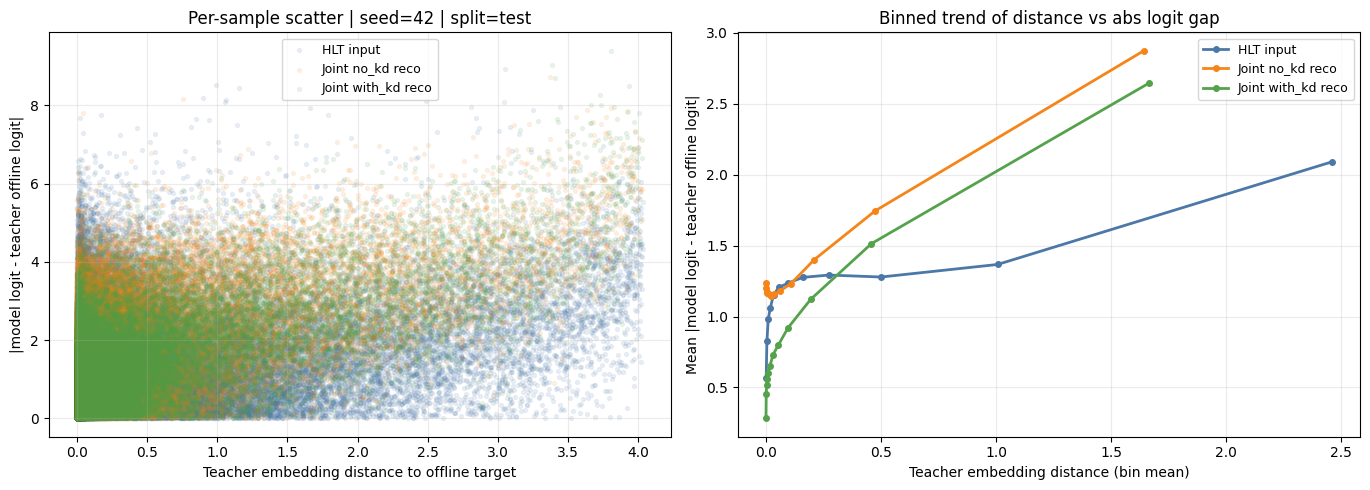

In [11]:
# 分析 hlt / joint_no_kd / joint_with_kd 的 teacher embedding distance
# 与它们各自 logit 相对 offline teacher logit 的差距是否相关。
# 这个 cell 只依赖前面的数据读取 / 配置 / dataset cell，不依赖训练汇总 cell。

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

TARGET_REPEAT_SEED = 42
TARGET_SPLIT = 'test'  # 可选: 'train' / 'val' / 'test'
TARGET_BATCH_SIZE = int(CONFIG['training'].get('batch_size', 256))
TARGET_RUN_NAME = str(globals().get('RUN_NAME', 'unsmear_transformer_sharedencoder_delta_gate_joint_repeat3'))

if TARGET_SPLIT not in {'train', 'val', 'test'}:
    raise ValueError(f'Unsupported TARGET_SPLIT: {TARGET_SPLIT}')

run_dir = Path(REPEAT_DIR)
if run_dir.name != 'repeats':
    run_dir = Path(MODULE_DIR) / 'runs' / TARGET_RUN_NAME / 'repeats'
if not run_dir.is_dir():
    raise FileNotFoundError(f'Repeat directory not found: {run_dir}')

repeat_candidates = sorted([p for p in run_dir.iterdir() if p.is_dir() and p.name.endswith(f'_seed_{int(TARGET_REPEAT_SEED)}')])
if not repeat_candidates:
    raise FileNotFoundError(f'No repeat folder found for seed={int(TARGET_REPEAT_SEED)} under {run_dir}')
repeat_dir = repeat_candidates[-1]
repeat_ckpt_dir = repeat_dir / 'ckpts'

teacher_ckpt = repeat_ckpt_dir / 'teacher_offline.pt'
hlt_ckpt = repeat_ckpt_dir / 'student_hlt.pt'
joint_no_kd_ckpt = repeat_ckpt_dir / 'joint_sharedencoder_no_kd.pt'
joint_with_kd_ckpt = repeat_ckpt_dir / 'joint_sharedencoder_with_kd.pt'
for required_path in [teacher_ckpt, hlt_ckpt, joint_no_kd_ckpt, joint_with_kd_ckpt]:
    if not required_path.is_file():
        raise FileNotFoundError(f'Checkpoint not found: {required_path}')

split_to_idx = {
    'train': train_idx,
    'val': val_idx,
    'test': test_idx,
}
sel_idx = split_to_idx[TARGET_SPLIT]
analysis_ds = tool.JointJetDataset(
    x_joint[sel_idx],
    y_joint[sel_idx],
    common_mask[sel_idx],
    labels[sel_idx],
    weights[sel_idx],
)
analysis_loader = DataLoader(analysis_ds, batch_size=TARGET_BATCH_SIZE, shuffle=False)

teacher_model = ParticleTransformerKD(**CONFIG['tagger']).to(device)
tool.load_checkpoint(teacher_model, str(teacher_ckpt), map_location=device)
teacher_model.eval()

hlt_model = ParticleTransformerKD(**CONFIG['tagger']).to(device)
tool.load_checkpoint(hlt_model, str(hlt_ckpt), map_location=device)
hlt_model.eval()

joint_no_kd_model = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
tool.load_checkpoint(joint_no_kd_model, str(joint_no_kd_ckpt), map_location=device)
joint_no_kd_model.eval()

joint_with_kd_model = SharedEncoderUnsmearClassifier(**CONFIG['joint_model']).to(device)
tool.load_checkpoint(joint_with_kd_model, str(joint_with_kd_ckpt), map_location=device)
joint_with_kd_model.eval()

@torch.no_grad()
def extract_teacher_embedding(model, x, mask):
    B, S, _ = x.shape
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    h = x.reshape(B * S, model.input_dim)
    h = model.input_proj(h)
    h = h.reshape(B, S, model.embed_dim)
    h = model.transformer(h, src_key_padding_mask=~mask)
    q = model.pool_query.expand(B, -1, -1)
    pooled, _ = model.pool_attn(q, h, h, key_padding_mask=~mask, need_weights=False)
    z = model.norm(pooled.squeeze(1))
    return z


def per_sample_embedding_mse(candidate_z, target_z):
    return torch.mean((candidate_z - target_z) ** 2, dim=-1)


@torch.no_grad()
def collect_distance_logit_rows(teacher, hlt, joint_no_kd, joint_with_kd, loader):
    rows = []
    sample_offset = 0
    for batch_idx, batch in enumerate(loader):
        x = batch['x'].to(device)
        y_off = batch['y_unsmear'].to(device)
        m = batch['mask'].to(device)
        y_cls = batch['label'].to(device)
        w = batch['weight'].to(device)

        teacher_off_logits = teacher(y_off, m).squeeze(-1)
        hlt_logits = hlt(x, m).squeeze(-1)
        reco_no_kd, joint_no_kd_logits = joint_no_kd(x, m)
        reco_with_kd, joint_with_kd_logits = joint_with_kd(x, m)
        joint_no_kd_logits = joint_no_kd_logits.squeeze(-1)
        joint_with_kd_logits = joint_with_kd_logits.squeeze(-1)

        target_z = extract_teacher_embedding(teacher, y_off, m)
        hlt_z = extract_teacher_embedding(teacher, x, m)
        reco_no_kd_z = extract_teacher_embedding(teacher, reco_no_kd, m)
        reco_with_kd_z = extract_teacher_embedding(teacher, reco_with_kd, m)

        teacher_off_logits_np = teacher_off_logits.detach().cpu().numpy()
        label_np = y_cls.detach().cpu().numpy()
        weight_np = w.detach().cpu().numpy()

        per_method = {
            'hlt_input': {
                'distance': per_sample_embedding_mse(hlt_z, target_z).detach().cpu().numpy(),
                'logit': hlt_logits.detach().cpu().numpy(),
            },
            'joint_no_kd_reco': {
                'distance': per_sample_embedding_mse(reco_no_kd_z, target_z).detach().cpu().numpy(),
                'logit': joint_no_kd_logits.detach().cpu().numpy(),
            },
            'joint_with_kd_reco': {
                'distance': per_sample_embedding_mse(reco_with_kd_z, target_z).detach().cpu().numpy(),
                'logit': joint_with_kd_logits.detach().cpu().numpy(),
            },
        }

        for method_name, payload in per_method.items():
            distance_np = payload['distance']
            logit_np = payload['logit']
            signed_gap_np = logit_np - teacher_off_logits_np
            abs_gap_np = np.abs(signed_gap_np)
            for i in range(distance_np.shape[0]):
                rows.append({
                    'sample_index': int(sample_offset + i),
                    'batch_idx': int(batch_idx),
                    'method': str(method_name),
                    'label': float(label_np[i]),
                    'weight': float(weight_np[i]),
                    'teacher_embedding_distance': float(distance_np[i]),
                    'teacher_offline_logit': float(teacher_off_logits_np[i]),
                    'model_logit': float(logit_np[i]),
                    'logit_gap_signed': float(signed_gap_np[i]),
                    'logit_gap_abs': float(abs_gap_np[i]),
                })
        sample_offset += int(x.shape[0])
    return pd.DataFrame(rows)


def corr_safe(series_a, series_b, method='pearson'):
    s = pd.DataFrame({'a': series_a, 'b': series_b}).dropna()
    if len(s) < 2:
        return np.nan
    if s['a'].std(ddof=0) < 1e-12 or s['b'].std(ddof=0) < 1e-12:
        return np.nan
    return float(s['a'].corr(s['b'], method=method))


def build_binned_curve(df_method, n_bins=12):
    df_local = df_method[['teacher_embedding_distance', 'logit_gap_abs']].dropna().copy()
    if len(df_local) < max(20, n_bins):
        return pd.DataFrame()
    try:
        df_local['dist_bin'] = pd.qcut(df_local['teacher_embedding_distance'], q=n_bins, duplicates='drop')
    except Exception:
        return pd.DataFrame()
    grouped = df_local.groupby('dist_bin', observed=False).agg(
        distance_bin_mean=('teacher_embedding_distance', 'mean'),
        abs_gap_mean=('logit_gap_abs', 'mean'),
        count=('logit_gap_abs', 'size'),
    ).reset_index(drop=True)
    return grouped


distance_logit_df = collect_distance_logit_rows(
    teacher_model,
    hlt_model,
    joint_no_kd_model,
    joint_with_kd_model,
    analysis_loader,
)
if distance_logit_df.empty:
    raise RuntimeError('No distance/logit rows were collected.')

method_order = ['hlt_input', 'joint_no_kd_reco', 'joint_with_kd_reco']
display_name_map = {
    'hlt_input': 'HLT input',
    'joint_no_kd_reco': 'Joint no_kd reco',
    'joint_with_kd_reco': 'Joint with_kd reco',
}
plot_color_map = {
    'hlt_input': '#4C78A8',
    'joint_no_kd_reco': '#F58518',
    'joint_with_kd_reco': '#54A24B',
}

summary_rows = []
binned_curves = {}
for method_name in method_order:
    df_method = distance_logit_df[distance_logit_df['method'] == method_name].copy()
    if df_method.empty:
        continue
    summary_rows.append({
        'method': str(method_name),
        'n_samples': int(len(df_method)),
        'distance_mean': float(df_method['teacher_embedding_distance'].mean()),
        'abs_logit_gap_mean': float(df_method['logit_gap_abs'].mean()),
        'abs_logit_gap_weighted_mean': float(np.average(df_method['logit_gap_abs'].to_numpy(dtype=np.float64), weights=df_method['weight'].to_numpy(dtype=np.float64))) if float(df_method['weight'].sum()) > 0 else float(df_method['logit_gap_abs'].mean()),
        'pearson_distance_vs_abs_gap': corr_safe(df_method['teacher_embedding_distance'], df_method['logit_gap_abs'], method='pearson'),
        'spearman_distance_vs_abs_gap': corr_safe(df_method['teacher_embedding_distance'], df_method['logit_gap_abs'], method='spearman'),
        'pearson_distance_vs_signed_gap': corr_safe(df_method['teacher_embedding_distance'], df_method['logit_gap_signed'], method='pearson'),
        'spearman_distance_vs_signed_gap': corr_safe(df_method['teacher_embedding_distance'], df_method['logit_gap_signed'], method='spearman'),
    })
    binned_curves[method_name] = build_binned_curve(df_method, n_bins=12)
summary_df = pd.DataFrame(summary_rows)
summary_df['method'] = pd.Categorical(summary_df['method'], categories=method_order, ordered=True)
summary_df = summary_df.sort_values('method').reset_index(drop=True)
summary_view = summary_df.copy()
summary_view['method'] = summary_view['method'].map(display_name_map)

safe_split = str(TARGET_SPLIT)
rows_out = os.path.join(TABLE_DIR, f'teacher_embedding_logit_relation_rows_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.csv')
summary_out = os.path.join(TABLE_DIR, f'teacher_embedding_logit_relation_summary_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.csv')
distance_logit_df.to_csv(rows_out, index=False)
summary_df.to_csv(summary_out, index=False)

print('Run name:', TARGET_RUN_NAME)
print('Repeat dir:', repeat_dir)
print('Split:', TARGET_SPLIT)
print()
print('Question being tested: does larger teacher embedding distance correspond to larger logit gap from offline teacher?')
print('For logit gap, smaller is better; for distance, smaller is better.')
print()
print(summary_view.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print()
print('Saved rows:', rows_out)
print('Saved summary:', summary_out)

display(summary_view)
display(distance_logit_df.head())

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.0))
for method_name in method_order:
    df_method = distance_logit_df[distance_logit_df['method'] == method_name]
    if df_method.empty:
        continue
    axes[0].scatter(
        df_method['teacher_embedding_distance'].to_numpy(dtype=float),
        df_method['logit_gap_abs'].to_numpy(dtype=float),
        s=8,
        alpha=0.10,
        color=plot_color_map[method_name],
        label=display_name_map[method_name],
    )
axes[0].set_xlabel('Teacher embedding distance to offline target')
axes[0].set_ylabel('|model logit - teacher offline logit|')
axes[0].set_title(f'Per-sample scatter | seed={int(TARGET_REPEAT_SEED)} | split={TARGET_SPLIT}')
axes[0].grid(True, alpha=0.25)
axes[0].legend(fontsize=9)

for method_name in method_order:
    curve_df = binned_curves.get(method_name, pd.DataFrame())
    if curve_df.empty:
        continue
    axes[1].plot(
        curve_df['distance_bin_mean'].to_numpy(dtype=float),
        curve_df['abs_gap_mean'].to_numpy(dtype=float),
        marker='o',
        ms=4,
        lw=2.0,
        color=plot_color_map[method_name],
        label=display_name_map[method_name],
    )
axes[1].set_xlabel('Teacher embedding distance (bin mean)')
axes[1].set_ylabel('Mean |model logit - teacher offline logit|')
axes[1].set_title('Binned trend of distance vs abs logit gap')
axes[1].grid(True, alpha=0.25)
axes[1].legend(fontsize=9)

fig.tight_layout()
fig_out = os.path.join(FIG_DIR, f'teacher_embedding_vs_logit_gap_seed_{int(TARGET_REPEAT_SEED)}_{safe_split}.png')
plt.savefig(fig_out, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_out)
plt.show()